In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm

import nltk
import gensim

from konlpy.tag import Mecab
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import pickle
import unicodedata
import copy
import time
import csv

from sklearn.model_selection import train_test_split

print(np.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

1.26.2
2.3.3
2.7.1+cu118
3.9.4
4.4.0


In [198]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Step 1. 데이터 다운로드
- https://github.com/songys/Chatbot_data

### 원본 데이터 살펴보기

In [199]:
# 데이터 다운로드 및 읽기
try:
    data = pd.read_csv('ChatbotData.csv')
    questions = data['Q'].tolist()
    answers = data['A'].tolist()
    print(f"데이터 로드 완료! 총 {len(questions)}개의 쌍이 존재합니다.")
except FileNotFoundError:
    print("ChatbotData.csv 파일을 찾을 수 없습니다. 경로를 확인해 주세요.")

데이터 로드 완료! 총 11823개의 쌍이 존재합니다.


=== 질문(Q) 글자 수 통계 ===
최대 길이: 56
최소 길이: 1
평균 길이: 12.88
중앙값(Median): 12.0
95퍼센타일 (대부분의 문장이 포함되는 길이): 25.0
99퍼센타일: 32.0

=== 답변(A) 글자 수 통계 ===
최대 길이: 76
최소 길이: 1
평균 길이: 15.02
중앙값(Median): 14.0
95퍼센타일 (대부분의 문장이 포함되는 길이): 27.0
99퍼센타일: 37.0



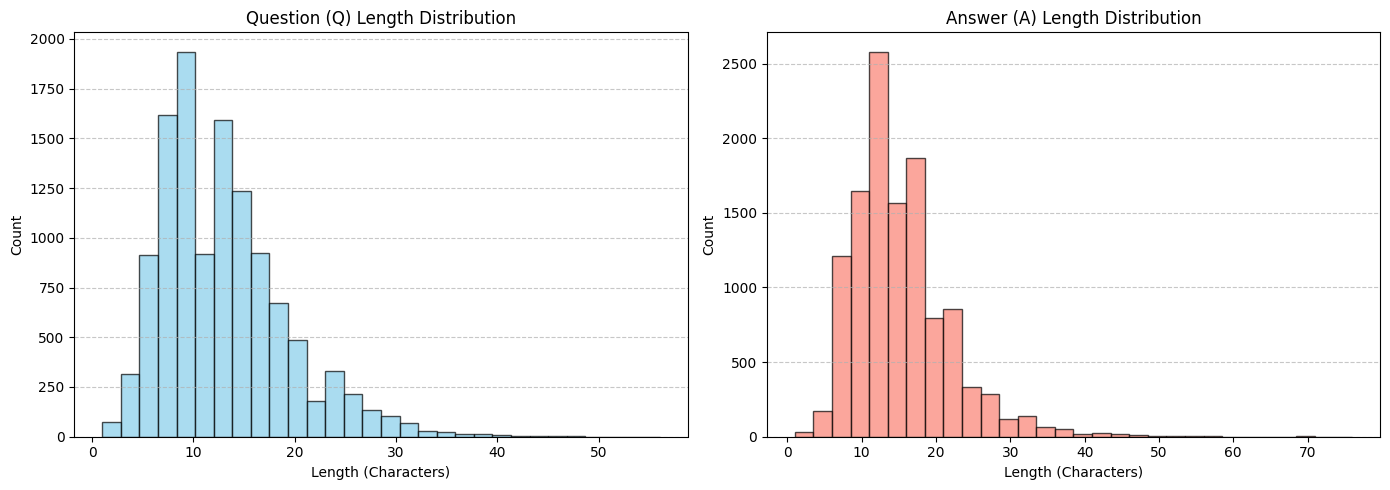

In [200]:
# 정제 전 글자 수(Character Count) 및 띄어쓰기 기준 단어 수(Word Count) 계산
q_char_lens = [len(str(s)) for s in questions]
a_char_lens = [len(str(s)) for s in answers]

q_word_lens = [len(str(s).split()) for s in questions]
a_word_lens = [len(str(s).split()) for s in answers]

# 통계치 정밀 분석 함수
def print_stats(lens, title):
    print(f"=== {title} 통계 ===")
    print(f"최대 길이: {np.max(lens)}")
    print(f"최소 길이: {np.min(lens)}")
    print(f"평균 길이: {np.mean(lens):.2f}")
    print(f"중앙값(Median): {np.median(lens)}")
    print(f"95퍼센타일 (대부분의 문장이 포함되는 길이): {np.percentile(lens, 95)}")
    print(f"99퍼센타일: {np.percentile(lens, 99)}\n")

# 통계 출력 (우선 직관적인 '글자 수' 기준으로 먼저 확인해봅니다)
print_stats(q_char_lens, "질문(Q) 글자 수")
print_stats(a_char_lens, "답변(A) 글자 수")

# 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 질문 분포
axes[0].hist(q_char_lens, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Question (Q) Length Distribution')
axes[0].set_xlabel('Length (Characters)')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 답변 분포
axes[1].hist(a_char_lens, bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Answer (A) Length Distribution')
axes[1].set_xlabel('Length (Characters)')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Step 2. 데이터 정제

In [201]:
# 데이터 정제 함수
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    # 영문자, 한글, 숫자, 주요 특수문자(?, !, ., ,) 제외하고 제거
    sentence = re.sub(r"[^a-zA-Z가-힣0-9?,!.,\s]", "", sentence)
    # 연속된 공백을 단일 공백으로 압축하고 앞뒤 공백 제거
    sentence = re.sub(r"[\s]+", " ", sentence).strip()
    return sentence

## Step 3. 데이터 토큰화

In [202]:
# mecab 클래스 초기화
mecab = Mecab(dicpath="C:/Users/sr/anaconda3/envs/aiffel_nlp/Lib/site-packages/mecab-ko-dic")

# 형태소 분석 예시
tokens = mecab.morphs("아버지가방에들어가신다")
print(tokens)

['아버지', '가', '방', '에', '들어가', '신다']


### 문장 길이와 토큰개수 관계 확인

원본 데이터 분석


<Figure size 1000x800 with 0 Axes>

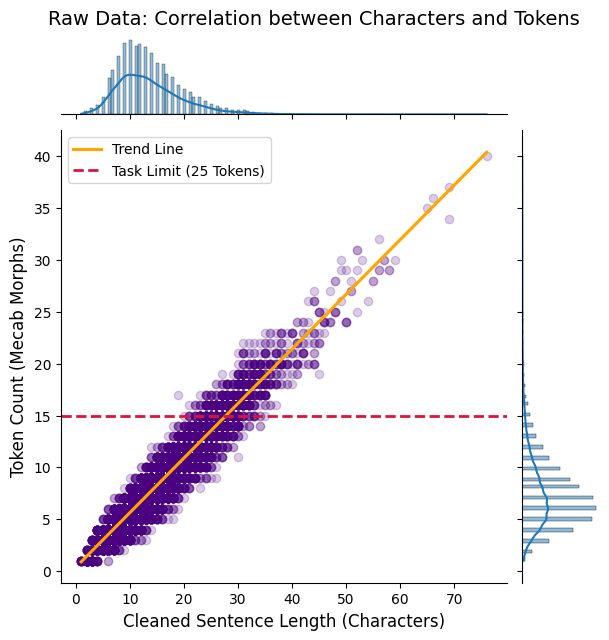

[원본 데이터 분석 결과 안내]
- 정제 후 평균 글자 수: 13.9자
- 정제 후 평균 토큰 개수: 7.7개
[연구 인사이트]
  Mecab 토큰 기준 '15개 이하'인 문장들은 안전하게 글자 수 27자 이하에 99% 분포하고 있습니다.
  즉, 글자 수 기준 27자가 넘는 문장들이 주로 build_corpus에서 필터링되어 탈락할 것입니다.


In [203]:
def analyze_raw_distribution(raw_questions, raw_answers, mecab_tokenizer):
    # 질문과 답변을 합쳐서 전체적인 언어적 특성을 파악합니다.
    all_sentences = list(raw_questions) + list(raw_answers)
    
    char_lengths = []
    token_counts = []
    
    print("원본 데이터 분석")
    for sentence in all_sentences:
        clean_sentence = preprocess_sentence(str(sentence))
        
        char_len = len(clean_sentence)
        token_cnt = len(mecab_tokenizer.morphs(clean_sentence))
        
        char_lengths.append(char_len)
        token_counts.append(token_cnt)
        
    # 시각화 설정
    plt.figure(figsize=(10, 8))
    grid = sns.jointplot(x=char_lengths, y=token_counts, kind='reg', 
                         scatter_kws={'alpha':0.2, 'color':'indigo'}, 
                         line_kws={'color':'orange', 'label':'Trend Line'})
    
    grid.set_axis_labels('Cleaned Sentence Length (Characters)', 'Token Count (Mecab Morphs)', fontsize=12)
    
    # 기준선인 15토큰을 가로선으로 표시
    grid.ax_joint.axhline(y=15, color='crimson', linestyle='--', linewidth=2, 
                          label='Task Limit (25 Tokens)')
    
    # 통계치 계산
    char_lengths = np.array(char_lengths)
    token_counts = np.array(token_counts)
    
    # 토큰이 15개 이하인 데이터들이 글자수로는 대략 몇 자 이하에 분포하는지 계산 (99% 분위수 기준)
    under_15_chars = char_lengths[token_counts <= 15]
    safe_char_limit = int(np.percentile(under_15_chars, 99)) if len(under_15_chars) > 0 else 0
    
    plt.suptitle('Raw Data: Correlation between Characters and Tokens', y=1.02, fontsize=14)
    grid.ax_joint.legend(loc='upper left')
    plt.show()
    
    print(f"[원본 데이터 분석 결과 안내]")
    print(f"- 정제 후 평균 글자 수: {np.mean(char_lengths):.1f}자")
    print(f"- 정제 후 평균 토큰 개수: {np.mean(token_counts):.1f}개")
    print(f"[연구 인사이트]")
    print(f"  Mecab 토큰 기준 '15개 이하'인 문장들은 안전하게 글자 수 {safe_char_limit}자 이하에 99% 분포하고 있습니다.")
    print(f"  즉, 글자 수 기준 {safe_char_limit}자가 넘는 문장들이 주로 build_corpus에서 필터링되어 탈락할 것입니다.")

# 실행
analyze_raw_distribution(questions, answers, mecab)

### 코퍼스 빌드

In [204]:
def build_corpus(src_data, tgt_data, max_len=25):
    que_corpus = []
    ans_corpus = []
    
    # 그래프 시각화를 위해 "전처리 직후"의 글자 수를 저장할 리스트
    preprocessed_q_lens = []
    preprocessed_a_lens = []
    
    # 소스는 소스대로, 타겟은 타겟대로 독립적인 중복 체크를 위한 셋(Set)
    seen_que = set()
    seen_ans = set()
    
    # --- [로그 기록용 카운터 시작] ---
    total_input = len(src_data)
    length_dropped = 0   # 토큰 길이 제한(25초과)으로 탈락한 개수
    duplicate_dropped = 0 # 중복 조건에 걸려 탈락한 개수
    # ---------------------------------
    
    for src, tgt in zip(src_data, tgt_data):
        # 함수 내부에서 preprocess_sentence() 호출
        src_clean = preprocess_sentence(str(src))
        tgt_clean = preprocess_sentence(str(tgt))
        
        # 1차 그래프용 데이터 수집 (전처리 후 순수 글자 수)
        preprocessed_q_lens.append(len(src_clean))
        preprocessed_a_lens.append(len(tgt_clean))
        
        # Mecab 토큰화
        src_tokens = mecab.morphs(src_clean)
        tgt_tokens = mecab.morphs(tgt_clean)
        
        # 1. 조건 검사: 문장 길이 필터링 (질문이나 답변 중 하나라도 25토큰을 초과하면 탈락)
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            
            src_str = " ".join(src_tokens)
            tgt_str = " ".join(tgt_tokens)
            
            # 2. 조건 검사: 소스는 소스대로, 타겟은 타겟대로 독립 검사하여 중복 제거
            if src_str not in seen_que and tgt_str not in seen_ans:
                seen_que.add(src_str)
                seen_ans.add(tgt_str)
                
                que_corpus.append(src_tokens)
                ans_corpus.append(tgt_tokens)
            else:
                # 길이 조건은 통과했으나 중복에 걸린 경우
                duplicate_dropped += 1
        else:
            # 토큰 개수가 25개를 초과하여 탈락한 경우
            length_dropped += 1
                
    # --- 상세 로그 프린트 영역 ---
    print("=" * 45)
    print("📋 [Step 3: 코퍼스 빌드 데이터 필터링 리포트]")
    print("=" * 45)
    print(f" 🔹 입력 원본 데이터 쌍 총합 : {total_input}개")
    print(f" ❌ 토큰 길이 제한 초과 탈락 : {length_dropped}개 (질문/답변 > {max_len} 토큰)")
    print(f" ❌ 독립적 문장 중복으로 탈락 : {duplicate_dropped}개")
    print("-" * 45)
    print(f" 🎉 최종 빌드 완료 코퍼스  : {len(que_corpus)}개")
    print(f" 📊 데이터 유실률(Drop Rate) : {((length_dropped + duplicate_dropped) / total_input) * 100:.2f}%")
    print("=" * 45)
    
    # 시각화용 데이터와 코퍼스를 반환
    return que_corpus, ans_corpus, preprocessed_q_lens, preprocessed_a_lens

In [205]:
# 코퍼스 빌드 실행
MAX_TOKEN_LENGTH = 15
que_corpus, ans_corpus, pre_q_lens, pre_a_lens = build_corpus(questions, answers, max_len=MAX_TOKEN_LENGTH)


📋 [Step 3: 코퍼스 빌드 데이터 필터링 리포트]
 🔹 입력 원본 데이터 쌍 총합 : 11823개
 ❌ 토큰 길이 제한 초과 탈락 : 792개 (질문/답변 > 15 토큰)
 ❌ 독립적 문장 중복으로 탈락 : 3943개
---------------------------------------------
 🎉 최종 빌드 완료 코퍼스  : 7088개
 📊 데이터 유실률(Drop Rate) : 40.05%


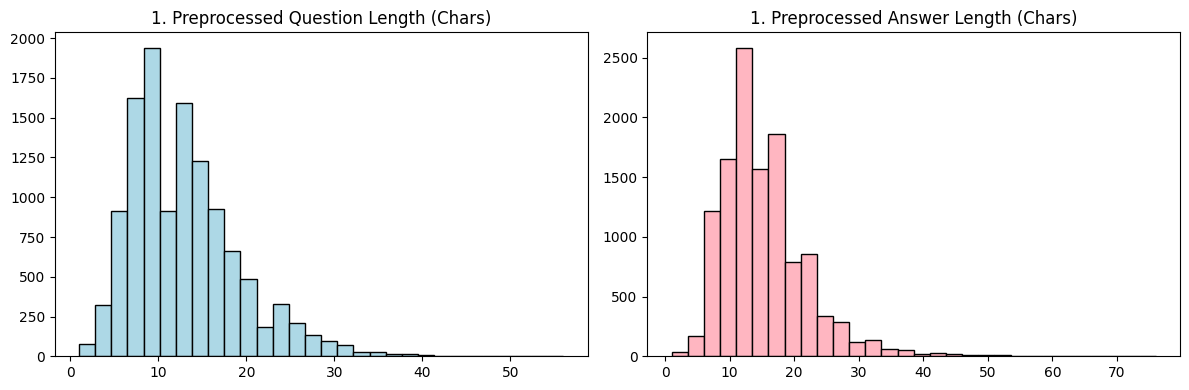

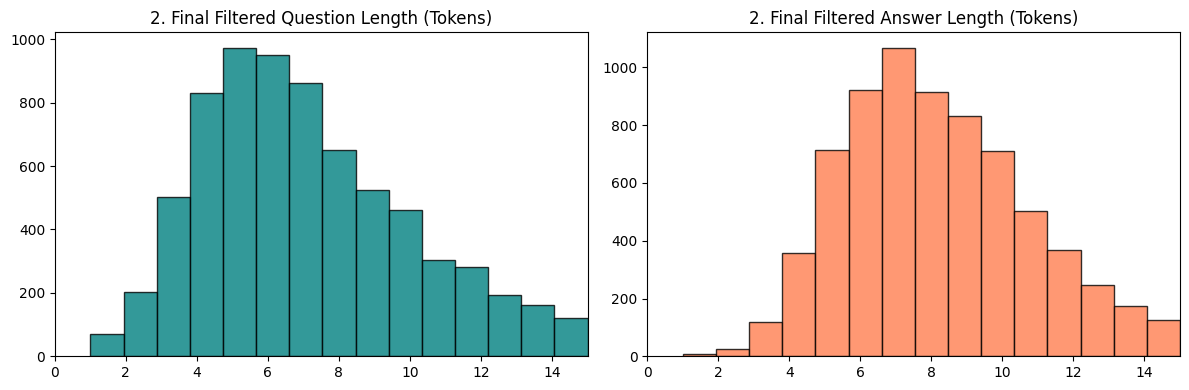

In [206]:
# [그래프 1] build_corpus 내부에서 수행된 전처리 직후(글자 수) 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pre_q_lens, bins=30, color='lightblue', edgecolor='black')
axes[0].set_title('1. Preprocessed Question Length (Chars)')
axes[1].hist(pre_a_lens, bins=30, color='lightpink', edgecolor='black')
axes[1].set_title('1. Preprocessed Answer Length (Chars)')
plt.tight_layout()
plt.show()

# [그래프 2] 최종 필터링까지 완료된 코퍼스(Mecab 토큰 수) 분포
q_final_lens = [len(t) for t in que_corpus]
a_final_lens = [len(t) for t in ans_corpus]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(q_final_lens, bins=15, color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title('2. Final Filtered Question Length (Tokens)')
axes[0].set_xlim(0, 15)

axes[1].hist(a_final_lens, bins=15, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('2. Final Filtered Answer Length (Tokens)')
axes[1].set_xlim(0, 15)

plt.tight_layout()
plt.show()

In [207]:
def verify_corpus_pairs(que_data, ans_data, num_samples=20):
    # 두 코퍼스의 전체 길이가 일치하는지 먼저 확인
    assert len(que_data) == len(ans_data), f"❌ 경고: 질문 코퍼스({len(que_data)}개)와 답변 코퍼스({len(ans_data)}개)의 전체 개수가 일치하지 않습니다!"
    
    total_size = len(que_data)
    print(f"✅ 전체 데이터 개수 일치 확인: 총 {total_size}개의 쌍이 존재합니다.")
    print(f"🔄 이 중 {num_samples}개의 샘플을 무작위로 추출하여 짝이 맞는지 검증합니다.\n")
    
    # 무작위 인덱스 num_samples(20개) 추출
    random_indices = random.sample(range(total_size), num_samples)
    
    sample_records = []
    for idx in random_indices:
        # 현재 토큰 리스트 상태이므로, 보기 편하게 공백으로 합쳐서 출력문 구성
        q_text = " ".join(que_data[idx])
        a_text = " ".join(ans_data[idx])
        
        sample_records.append({
            'Index': idx,
            '질문 코퍼스 (Mecab 토큰 추출)': q_text,
            '답변 코퍼스 (Mecab 토큰 추출)': a_text
        })
    
    df_verify = pd.DataFrame(sample_records)
    return df_verify


In [208]:
# 20개 무작위 샘플 검증 실행
df_verification_result = verify_corpus_pairs(que_corpus, ans_corpus, num_samples=20)

# 화면에 출력
df_verification_result

✅ 전체 데이터 개수 일치 확인: 총 7088개의 쌍이 존재합니다.
🔄 이 중 20개의 샘플을 무작위로 추출하여 짝이 맞는지 검증합니다.



,Index,질문 코퍼스 (Mecab 토큰 추출),답변 코퍼스 (Mecab 토큰 추출)
0,5238,나 사랑 하 는 사람 생겼 어,축하 해요 . 예쁜 사랑 하 길 바라 요 .
1,912,말 을 해 놓 고 후회 돼 죽 겠 어,두고두고 후회 하 겠 네요 .
2,204,그냥 자 는 거 아니 지 ?,많이 피곤 한가 봐요 .
3,6074,썸 타 다 지쳤 어,지친 거 티 내보 세요 .
4,2253,핸드폰 바꿀 때 가 된 듯,오래 쓰 셨 나 봐요 .
5,2006,지금 자 면 밤 에 못 자 겠 지 ?,낮잠 은 20 분 만 자 세요 .
6,1828,이제 은퇴 해야 하나 ?,끝 까지 해 보 세요 .
7,1143,버려야 되 는데 . .,잘 버리 는 것 도 중요 해요 .
8,6033,썸 타 는 거 티 내 고 싶 진 않 아 .,누구 에게 요 ?
9,839,떠나 요 제주도,여행 좋 죠 !


## Step 4. Augmentation

In [209]:
tsv_vocab_dict = {}
tsv_vectors = {}

# 대괄호, 줄바꿈, 다중 공백을 무력화하고 오직 [단어]와 [숫자들]만 뽑아내는 강력한 정규식 패턴
pattern = re.compile(r'([가-힣a-zA-Z0-9_+\-]+)\s+\[([^\]]+)\]')

print("🔄 특수 포맷의 ko.tsv 파일을 정밀 파싱 중...")

with open("ko.tsv", "r", encoding="utf-8") as f:
    # 파일 전체를 하나의 문자열로 읽어 줄바꿈에 상관없이 패턴을 추적합니다.
    content = f.read()
    
    # 패턴 매칭 시작
    matches = pattern.findall(content)
    
    for word, vector_str in matches:
        # 맨 앞의 '0'이나 인덱스용 숫자 형태는 단어에서 제외
        if word.isdigit():
            continue
            
        try:
            # 대괄호 안의 숫자 스트링에서 공백, 줄바꿈을 다 지우고 순수 숫자 리스트로 변환
            clean_vector_str = vector_str.replace('\n', ' ').strip()
            vector_elements = [float(x) for x in clean_vector_str.split() if x]
            
            if vector_elements:
                tsv_vocab_dict[word] = True
                tsv_vectors[word] = np.array(vector_elements)
                
        except ValueError:
            continue

print("-" * 60)
print(f"✅ 로드 성공! 총 {len(tsv_vocab_dict)}개의 단어 벡터가 확보되었습니다.")

if tsv_vectors:
    sample_word = list(tsv_vectors.keys())[0]
    print(f"💡 정밀 파싱 샘플 확인 ➔ 단어: '{sample_word}' | 벡터 크기: {len(tsv_vectors[sample_word])}차원")

🔄 특수 포맷의 ko.tsv 파일을 정밀 파싱 중...
------------------------------------------------------------
✅ 로드 성공! 총 30121개의 단어 벡터가 확보되었습니다.
💡 정밀 파싱 샘플 확인 ➔ 단어: '하' | 벡터 크기: 200차원


In [210]:
def find_most_similar_tsv_fast(target_word, tsv_vectors, topn=3):
    if target_word not in tsv_vectors:
        return []
    
    # 캐싱용 전역 행렬 바인딩 (최초 1회만 계산되도록 구동)
    if not hasattr(find_most_similar_tsv_fast, "matrix_built"):
        print("⚡ 초고속 연산을 위한 벡터 행렬 스캔 중 (최초 1회)...")
        find_most_similar_tsv_fast.words = list(tsv_vectors.keys())
        # 모든 벡터를 2차원 행렬로 적재
        matrix = np.array([tsv_vectors[w] for w in find_most_similar_tsv_fast.words])
        # 크기(Norm)로 나누어 미리 정규화 행렬 확보 (나누기 연산 최소화)
        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1.0 # 0 나누기 방지
        find_most_similar_tsv_fast.norm_matrix = matrix / norms
        find_most_similar_tsv_fast.matrix_built = True

    # 대상 단어 벡터 정규화
    target_vec = tsv_vectors[target_word]
    target_norm = np.linalg.norm(target_vec)
    if target_norm == 0: return []
    target_vec_norm = target_vec / target_norm

    # 행렬 곱으로 3만 개 단어의 유사도를 단 한 줄로 일괄 계산!
    sim_scores = np.dot(find_most_similar_tsv_fast.norm_matrix, target_vec_norm)
    
    # 본인 단어 제외 처리
    target_idx = find_most_similar_tsv_fast.words.index(target_word)
    sim_scores[target_idx] = -1.0 

    # 상위 topn 인덱스 추출
    top_indices = np.argsort(sim_scores)[::-1][:topn]
    
    return [(find_most_similar_tsv_fast.words[idx], sim_scores[idx]) for idx in top_indices]

In [211]:

def augment_with_tsv_3x_fixed(que_data, ans_data, vocab_dict, vectors):
    # 원본과 증강본들을 완전히 분리된 리스트로 관리하여 절대 인덱스가 밀리지 않게 합니다.
    orig_que, orig_ans = [], []
    aug1_que, aug1_ans = [], []
    aug2_que, aug2_ans = [], []
    
    success_count = 0
    print("\n🔄 [인덱스 고정 모드] 안전하게 3배 데이터 증강을 시작합니다...")

    for q_tokens, a_tokens in zip(que_data, ans_data):
        # 1. 원본 데이터 복사 및 저장
        q_base = copy.deepcopy(list(q_tokens))
        a_base = copy.deepcopy(list(a_tokens))
        
        orig_que.append(q_base)
        orig_ans.append(a_base)
        
        # 의미 있는 단어(길이 2 이상) 후보 인덱스 추출
        valid_indices = [idx for idx, token in enumerate(q_base) if len(token) > 1]
        
        # --- 증강본 A 생성 ---
        q_aug1 = copy.deepcopy(q_base)
        if valid_indices:
            idx1 = random.choice(valid_indices)
            target_word1 = unicodedata.normalize('NFC', q_base[idx1])
            if target_word1 in vocab_dict:
                sim_words1 = find_most_similar_tsv_fast(target_word1, vectors, topn=3)
                if sim_words1:
                    q_aug1[idx1] = unicodedata.normalize('NFC', random.choice(sim_words1)[0])
                    success_count += 1
        aug1_que.append(q_aug1)
        aug1_ans.append(a_base)  # 원본 답변과 1:1 매칭 보장
        
        # --- 증강본 B 생성 ---
        q_aug2 = copy.deepcopy(q_base)
        if valid_indices:
            idx2 = random.choice(valid_indices) # 다시 무작위 선택 (A와 같거나 다를 수 있음)
            target_word2 = unicodedata.normalize('NFC', q_base[idx2])
            if target_word2 in vocab_dict:
                sim_words2 = find_most_similar_tsv_fast(target_word2, vectors, topn=3)
                if sim_words2:
                    q_aug2[idx2] = unicodedata.normalize('NFC', random.choice(sim_words2)[0])
                    success_count += 1
        aug2_que.append(q_aug2)
        aug2_ans.append(a_base)  # 원본 답변과 1:1 매칭 보장
                        
    # 마지막에 순서대로 차곡차곡 합쳐줍니다.
    # 구조: [원본0, 원본1... 증강A0, 증강A1... 증강B0, 증강B1...]
    final_que = orig_que + aug1_que + aug2_que
    final_ans = orig_ans + aug1_ans + aug2_ans
    
    return final_que, final_ans, success_count, len(orig_que)

In [212]:
# 증강 함수를 실행하기 전, 원본 텍스트 코퍼스를 독립적으로 복사해 둡니다.
que_corpus_orig = list(que_corpus)  # 질문 원본 텍스트 리스트 복사
ans_corpus_orig = list(ans_corpus)  # 답변 원본 텍스트 리스트 복사

print(f"🌱 증강 전 원본 텍스트 백업 완료! (개수: {len(que_corpus_orig)}개)")
print("-" * 60)

🌱 증강 전 원본 텍스트 백업 완료! (개수: 7088개)
------------------------------------------------------------


In [213]:
# 증강
final_que_corpus, final_ans_corpus, success_cnt, original_len = augment_with_tsv_3x_fixed(
    que_corpus, ans_corpus, tsv_vocab_dict, tsv_vectors
)


🔄 [인덱스 고정 모드] 안전하게 3배 데이터 증강을 시작합니다...
⚡ 초고속 연산을 위한 벡터 행렬 스캔 중 (최초 1회)...


In [214]:
# 실제 알짜배기 새 문장(성공 건수)을 반영한 정확한 실질 배율 계산
real_augmented_len = original_len + success_cnt
real_ratio = real_augmented_len / original_len

print("=" * 60)
print(f"🎉 [3배 데이터 증강 최종 성공 리포트 - 인덱스 밀림 해결]")
print("=" * 60)
print(f" 🔹 증강 전 원본 개수        : {original_len}개")
print(f" 🔹 유의어 교체 성공 (알짜)   : {success_cnt}번")
print(f" 🔹 교체 실패 (원본 복사본)   : {len(final_que_corpus) - real_augmented_len}번")
print("-" * 60)
print(f" 🔹 증강 후 최종 파일 개수    : {len(final_que_corpus)}개 (정확히 {original_len * 3}개 세트 맞춤)")
print(f" 📈 겉보기 데이터 확장 배율   : {len(final_que_corpus) / original_len:.2f}배")
print(f" 🚀 [핵심] 실질 증강 배율      : {real_ratio:.2f}배 (중복 제외 알짜배기 데이터)")
print("=" * 60)

🎉 [3배 데이터 증강 최종 성공 리포트 - 인덱스 밀림 해결]
 🔹 증강 전 원본 개수        : 7088개
 🔹 유의어 교체 성공 (알짜)   : 10269번
 🔹 교체 실패 (원본 복사본)   : 3907번
------------------------------------------------------------
 🔹 증강 후 최종 파일 개수    : 21264개 (정확히 21264개 세트 맞춤)
 📈 겉보기 데이터 확장 배율   : 3.00배
 🚀 [핵심] 실질 증강 배율      : 2.45배 (중복 제외 알짜배기 데이터)


In [215]:
# =====================================================================
# 구조가 바뀐 것에 맞춘 정밀 샘플 검증 출력부
# =====================================================================
print("\n👀 [정밀 검증] 원본 문장 ➔ 증강 문장 복수 결과 비교 스캔 ")
print("-" * 60)

sample_sets_count = 20

for i in range(sample_sets_count):
    # 새로운 합치기 구조에 맞춰 인덱스를 정확하게 추적합니다.
    idx_orig = i
    idx_aug1 = original_len + i
    idx_aug2 = (original_len * 2) + i
    
    orig_q = " ".join(final_que_corpus[idx_orig])
    orig_a = " ".join(final_ans_corpus[idx_orig])
    
    aug1_q = " ".join(final_que_corpus[idx_aug1])
    diff1 = [f"'{o}'➔'{a}'" for o, a in zip(final_que_corpus[idx_orig], final_que_corpus[idx_aug1]) if o != a]
    diff1_str = diff1[0] if diff1 else "유의어 사전 공백으로 인해 원본 유지"
    
    aug2_q = " ".join(final_que_corpus[idx_aug2])
    diff2 = [f"'{o}'➔'{a}'" for o, a in zip(final_que_corpus[idx_orig], final_que_corpus[idx_aug2]) if o != a]
    diff2_str = diff2[0] if diff2 else "유의어 사전 공백으로 인해 원본 유지"
    
    print(f" 🌲 [Set {i + 1}]")
    print(f"  • 🟢 원본 문장  ➔  Q: {orig_q}  ||  A: {orig_a}")
    print(f"  • 🔹 증강 결과A ➔  Q: {aug1_q}   *(🔄 교체 포인트: {diff1_str})*")
    print(f"  • 🔸 증강 결과B ➔  Q: {aug2_q}   *(🔄 교체 포인트: {diff2_str})*")
    print("-" * 60)


👀 [정밀 검증] 원본 문장 ➔ 증강 문장 복수 결과 비교 스캔 
------------------------------------------------------------
 🌲 [Set 1]
  • 🟢 원본 문장  ➔  Q: 12 시 땡 !  ||  A: 하루 가 또 가 네요 .
  • 🔹 증강 결과A ➔  Q: 12 시 땡 !   *(🔄 교체 포인트: 유의어 사전 공백으로 인해 원본 유지)*
  • 🔸 증강 결과B ➔  Q: 12 시 땡 !   *(🔄 교체 포인트: 유의어 사전 공백으로 인해 원본 유지)*
------------------------------------------------------------
 🌲 [Set 2]
  • 🟢 원본 문장  ➔  Q: 1 지망 학교 떨어졌 어  ||  A: 위로 해 드립니다 .
  • 🔹 증강 결과A ➔  Q: 1 지망 학교 떨어졌 어   *(🔄 교체 포인트: 유의어 사전 공백으로 인해 원본 유지)*
  • 🔸 증강 결과B ➔  Q: 1 졸업 학교 떨어졌 어   *(🔄 교체 포인트: '지망'➔'졸업')*
------------------------------------------------------------
 🌲 [Set 3]
  • 🟢 원본 문장  ➔  Q: 3 박 4 일 놀 러 가 고 싶 다  ||  A: 여행 은 언제나 좋 죠 .
  • 🔹 증강 결과A ➔  Q: 3 박 4 일 놀 러 가 고 싶 다   *(🔄 교체 포인트: 유의어 사전 공백으로 인해 원본 유지)*
  • 🔸 증강 결과B ➔  Q: 3 박 4 일 놀 러 가 고 싶 다   *(🔄 교체 포인트: 유의어 사전 공백으로 인해 원본 유지)*
------------------------------------------------------------
 🌲 [Set 4]
  • 🟢 원본 문장  ➔  Q: ppl 심하 네  ||  A: 눈살 이 찌푸려 지 죠 .
  • 🔹 증강 결과A ➔  Q: ppl 강하 네   *(🔄 교체 포인트: '심하'➔

## Setp 5. 데이터 벡터화

- Answer 에만 시작, 종료 토큰 붙임

In [216]:
from collections import Counter

print("단어 사전(Vocabulary) 구축을 시작합니다...")

# 1. 특수 토큰 정의 (사전의 맨 앞에 배치)
PAD_TOKEN = "<PAD>"  # 문장 길이를 맞추는 패딩용 (0번)
UNK_TOKEN = "<UNK>"  # 사전에 없는 모르는 단어용 (1번)
SOS_TOKEN = "<SOS>"  # 답변 문장의 시작을 알리는용 (Start of Sentence, 2번)
EOS_TOKEN = "<EOS>"  # 답변 문장의 끝을 알리는용 (End of Sentence, 3번)

special_tokens = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

# 2. 전체 코퍼스(Q + A)에서 단어 빈도수 측정
all_tokens = []
for tokens in final_que_corpus:
    all_tokens.extend(tokens)
for tokens in final_ans_corpus:
    all_tokens.extend(tokens)

# 빈도수가 높은 순서대로 단어 정렬
counter = Counter(all_tokens)
vocab = special_tokens + [word for word, count in counter.most_common()]

# 3. 단어 <-> 인덱스 상호 변환 사전 생성
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for idx, word in enumerate(vocab)}

print("-" * 60)
print(f"✅ 단어 사전 빌드 완료!")
print(f" 🔹 구축된 총 고유 단어 수 (특수 토큰 포함) : {len(word_to_index)}개")
print(f" 🔹 상위 등록 샘플 사전: {list(word_to_index.items())[:8]}")
print("-" * 60)

단어 사전(Vocabulary) 구축을 시작합니다...
------------------------------------------------------------
✅ 단어 사전 빌드 완료!
 🔹 구축된 총 고유 단어 수 (특수 토큰 포함) : 7584개
 🔹 상위 등록 샘플 사전: [('<PAD>', 0), ('<UNK>', 1), ('<SOS>', 2), ('<EOS>', 3), ('.', 4), ('이', 5), ('하', 6), ('는', 7)]
------------------------------------------------------------


In [217]:
def tokenize_and_pad_fixed(corpus, is_answer=False):
    tensor = []
    for tokens in corpus:
        # 1. 답변(A) 데이터라면 문장 앞뒤로 시작(<SOS>)과 종료(<EOS>) 태그 부착
        if is_answer:
            processed_tokens = [SOS_TOKEN] + list(tokens) + [EOS_TOKEN]
        else:
            processed_tokens = list(tokens)
            
        # 2. 토큰을 사전에 등록된 정수 인덱스로 변환 (없는 단어는 <UNK> 토큰 번호로 방어)
        indexed_tokens = [word_to_index.get(word, word_to_index[UNK_TOKEN]) for word in processed_tokens]
        
        # 3. 토큰 수 기준 MAX_LEN(15)에 맞춰 패딩 또는 자르기
        if len(indexed_tokens) < MAX_TOKEN_LENGTH:
            # 부족하면 0번(<PAD>)으로 채우기
            indexed_tokens += [word_to_index[PAD_TOKEN]] * (MAX_TOKEN_LENGTH - len(indexed_tokens))
        else:
            # 15개가 넘어가면 뒤쪽을 잘라내기
            indexed_tokens = indexed_tokens[:MAX_TOKEN_LENGTH]
            if is_answer:
                # 답변이 잘렸더라도 마지막은 무조건 <EOS>로 닫히도록 안전장치 설정
                indexed_tokens[-1] = word_to_index[EOS_TOKEN]
                
        tensor.append(indexed_tokens)
        
    return np.array(tensor)

In [218]:
# =====================================================================
# 1. 증강된 데이터셋 (Augmented Dataset) 최종 숫자 행렬 변환
# =====================================================================
X_train = tokenize_and_pad_fixed(final_que_corpus, is_answer=False)
y_train = tokenize_and_pad_fixed(final_ans_corpus, is_answer=True)

# =====================================================================
# 2. 원본 데이터셋 (Original Dataset) 최종 숫자 행렬 변환
# =====================================================================
X_train_orig = tokenize_and_pad_fixed(que_corpus_orig, is_answer=False)
y_train_orig = tokenize_and_pad_fixed(ans_corpus_orig, is_answer=True)


In [219]:
# =====================================================================
# 3. 데이터 검증 및 크기(Shape) 비교 출력
# =====================================================================
print("=" * 60)
print("🎉 [Step 5. 데이터 벡터화 및 실험군 분리 최종 완료]")
print("=" * 60)
print(f" 🚀 [실험군 A : 증강 데이터셋]")
print(f"   - 입력 데이터 행렬 (X_train) 크기 : {X_train.shape}")
print(f"   - 출력 데이터 행렬 (y_train) 크기 : {y_train.shape}")
print("-" * 60)
print(f" 🌱 [실험군 B : 원본 데이터셋 (Ablation)]")
print(f"   - 입력 데이터 행렬 (X_train_orig) 크기 : {X_train_orig.shape}")
print(f"   - 출력 데이터 행렬 (y_train_orig) 크기 : {y_train_orig.shape}")
print("=" * 60)


# =====================================================================
# 4. 정수 인코딩 샘플 교차 검증 (상위 5개 복수 출력)
# =====================================================================
NUM_SAMPLES_TO_SHOW = 5  # 💡 확인하고 싶은 샘플 개수를 여기서 조절할 수 있습니다.

print(f"\n💡 [정수 인코딩 샘플 교차 검증 - 상위 {NUM_SAMPLES_TO_SHOW}개 데이터 비교]")

for idx in range(NUM_SAMPLES_TO_SHOW):
    print("=" * 60)
    print(f" 📍 [INDEX 번호 : {idx}]")
    print("=" * 60)
    print(" [실험군 A : 증강 데이터 샘플]")
    print(f"  • 원본 Q 텍스트 : {final_que_corpus[idx]}")
    print(f"  • 인코딩 숫자 Q : {X_train[idx]}")
    print(f"  • 원본 A 텍스트 : {final_ans_corpus[idx]}")
    print(f"  • 인코딩 숫자 A : {y_train[idx]}")
    print("-" * 60)
    print(" [실험군 B : 원본 데이터 샘플]")
    print(f"  • 원본 Q 텍스트 : {que_corpus_orig[idx]}")
    print(f"  • 인코딩 숫자 Q : {X_train_orig[idx]}")
    print(f"  • 원본 A 텍스트 : {ans_corpus_orig[idx]}")
    print(f"  • 인코딩 숫자 A : {y_train_orig[idx]}")

print("=" * 60)

🎉 [Step 5. 데이터 벡터화 및 실험군 분리 최종 완료]
 🚀 [실험군 A : 증강 데이터셋]
   - 입력 데이터 행렬 (X_train) 크기 : (21264, 15)
   - 출력 데이터 행렬 (y_train) 크기 : (21264, 15)
------------------------------------------------------------
 🌱 [실험군 B : 원본 데이터셋 (Ablation)]
   - 입력 데이터 행렬 (X_train_orig) 크기 : (7088, 15)
   - 출력 데이터 행렬 (y_train_orig) 크기 : (7088, 15)

💡 [정수 인코딩 샘플 교차 검증 - 상위 5개 데이터 비교]
 📍 [INDEX 번호 : 0]
 [실험군 A : 증강 데이터 샘플]
  • 원본 Q 텍스트 : ['12', '시', '땡', '!']
  • 인코딩 숫자 Q : [2054  185 2644   91    0    0    0    0    0    0    0    0    0    0
    0]
  • 원본 A 텍스트 : ['하루', '가', '또', '가', '네요', '.']
  • 인코딩 숫자 A : [  2 292   9 119   9  37   4   3   0   0   0   0   0   0   0]
------------------------------------------------------------
 [실험군 B : 원본 데이터 샘플]
  • 원본 Q 텍스트 : ['12', '시', '땡', '!']
  • 인코딩 숫자 Q : [2054  185 2644   91    0    0    0    0    0    0    0    0    0    0
    0]
  • 원본 A 텍스트 : ['하루', '가', '또', '가', '네요', '.']
  • 인코딩 숫자 A : [  2 292   9 119   9  37   4   3   0   0   0   0   0   0   0]
 📍 [INDE

## Step 6. 훈련하기

### transformer 구조

In [220]:
# =====================================================================
# 1. Positional Encoding 구현
# =====================================================================

def positional_encoding(pos, d_model):
    """
    pos: 문장의 최대 길이 (토큰 개수)
    d_model: 모델의 은닉층 차원 수 (Embedding 차원)
    """
    # 1. 특정 위치와 차원에 대한 고유 각도(Angle) 계산 함수 정의
    def cal_angle(position, i):
        # 수식: position / (10000 ^ (2i / d_model))
        return position / np.power(10000, (2 * (i // 2)) / float(d_model))

    # 2. 하나의 단어 위치에 대해 d_model 차원만큼의 각도 벡터를 생성
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    # 3. 문장 전체 길이(pos)만큼의 모든 단어 위치에 대한 각도 테이블 생성
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    # 4. 짝수 인덱스(0, 2, 4...) 차원에는 사인(Sin) 함수 적용
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  
    # 5. 홀수 인덱스(1, 3, 5...) 차원에는 코사인(Cos) 함수 적용
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  

    return sinusoid_table

In [221]:
# =====================================================================
# 2. Masking 생성기 구현
# =====================================================================

# 1. 패딩 마스크: 의미 없는 빈칸(<PAD>=0)이 있는 위치를 찾아내는 마스크
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    # 토큰 ID가 0인 곳은 True(1.0), 일반 단어는 False(0.0)로 변환 후 4차원으로 확장
    # Shape 변경: [batch_size, seq_len] ➔ [batch_size, 1, 1, seq_len] (어텐션 연산 맞춤)
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


# 2. 룩어헤드 마스크: 디코더 학습 시 미래의 토큰을 가리기 위한 상삼각행렬 마스크
def generate_lookahead_mask(size: int) -> torch.Tensor:
    # torch.triu(diagonal=1)을 통해 대각선 위쪽 성분만 1로 채우고 나머지는 0으로 설정
    # 행렬 예시: [[0, 1, 1], [0, 0, 1], [0, 0, 0]] ➔ 1이 표시된 곳이 미래 영역 (가려질 곳)
    return torch.triu(torch.ones(size, size), diagonal=1)


# 3. 종합 마스크 생성기: 인코더와 디코더 각각의 상황에 맞는 3대 마스크를 통합 생산
def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    # (1) 인코더 입력용: 질문 문장의 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # (2) 디코더-인코더 어텐션용: 디코더가 인코더 정보를 참조할 때 질문의 패딩 영역을 무시하기 위함
    dec_enc_mask = generate_padding_mask(src)

    # (3) 디코더 자기어텐션용: 답변 문장의 패딩 마스크와 미래 차단 마스크 결합
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  
    dec_tgt_padding_mask = generate_padding_mask(tgt)           

    # 배치(Batch)와 헤드(Head) 차원을 가상으로 확장 [1, 1, seq_len, seq_len]
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  

    # 연산 오류 방지: 마스크 연산 텐서들을 입력 데이터(src)와 동일한 하드웨어(GPU/CPU) 장치로 강제 전송
    dec_tgt_padding_mask = dec_tgt_padding_mask.to(src.device)
    dec_lookahead_mask = dec_lookahead_mask.to(src.device)

    # torch.max를 이용하여 두 마스크 중 하나라도 1(가려야 할 곳)인 지역을 최종 마스크(1)로 병합
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask


In [222]:
# =====================================================================
# 3. Attention 및 연산 Layer 구현
# =====================================================================


# 1. 멀티 헤드 어텐션: 질문을 다각도(num_heads)의 시선으로 쪼개서 분석하는 레이어
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads # 각 헤드(시선)가 담당할 하위 벡터 차원 수

        # 3대 핵심 벡터(Query, Key, Value) 변환을 위한 선형 매핑 레이어들
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model) # 모든 헤드를 합친 후 최종 조율하는 레이어

    # 스케일드 닷 프로덕트 어텐션: 실제 문맥 간의 가중치 점수를 수학적으로 매기는 핵심 수식
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        # Q와 K의 전치 행렬을 곱해 단어 간 연관성 점수(유사도) 추출
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # Softmax 연산 시 기울기 소실/폭주를 막기 위해 루트(d_k) 값으로 스케일링 분모 조절
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32, device=Q.device))

        # 마스크가 1인 곳(가려야 할 곳)에 -1,000,000,000 점을 강제로 더함
        # 이렇게 하면 이후 Softmax를 통과할 때 확률이 정확히 0%가 되어 인공지능이 무시하게 됨
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1) # 각 단어가 어디를 얼마나 볼지 확률 분포 생성
        out = torch.matmul(attentions, V)         # 가중치가 반영된 최종 문맥 의미 벡터 추출
        return out, attentions

    # 머리를 여러 개로 쪼개는 함수: [Batch, Seq, Dim] ➔ [Batch, Heads, Seq, Depth]
    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    # 쪼개진 머리들을 다시 하나로 통합하는 함수: [Batch, Heads, Seq, Depth] ➔ [Batch, Seq, Dim]
    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # 각각 입력받은 Q, K, V 데이터에 선형 가중치 매핑
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 멀티 헤드 구조로 차원 분할 변환
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 실제 어텐션 행렬 연산 수행
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # 다차원 연산 결과를 다시 원본 문장 차원으로 병합 및 최종 출력 생성
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights


# 2. 포지션 와이즈 피드포워드: 어텐션 층을 나온 벡터를 독립적으로 심층 연산하는 신경망
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff) # 차원을 확장하는 첫 번째 Dense 레이어
        self.fc2 = nn.Linear(d_ff, d_model) # 원래 차원으로 복원하는 두 번째 Dense 레이어
        self.relu = nn.ReLU()               # 비선형성을 부여하는 활성화 함수

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out


In [223]:
# =====================================================================
# 4. Encoder 및 Decoder 레이어 아키텍처 조립
# =====================================================================

# 1-1. 인코더 단일 층: [어텐션 ➔ 정규화/잔차연결 ➔ 피드포워드 ➔ 정규화/잔차연결]
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6) # 학습을 안정화하는 레이어 정규화 1
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6) # 학습을 안정화하는 레이어 정규화 2
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # 첫 번째 서브레이어 영역 (Self-Attention)
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual # 잔차 연결 (기존 입력값을 더해 조기 수렴 방지 및 그래디언트 확보)

        # 두 번째 서브레이어 영역 (Feed Forward Network)
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual # 잔차 연결
        return out, enc_attn


# 1-2. 인코더 마스터: 단일 인코더 층을 n_layers 층수만큼 쌓아 올린 구조
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # 파이토치 리스트 구조에 인코더 레이어들을 층층이 적층
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []
        # 아래층부터 위층까지 차례대로 통과시키며 특징 깊이 심화
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn) # 시각화를 위한 각 층의 어텐션 가중치 기록
        return out, enc_attns


# 2-1. 디코더 단일 층: [자기어텐션(미래차단) ➔ 인코더-디코더 어텐션(힌트받기) ➔ 피드포워드]
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)  # 자기 대화 문맥 파악용
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)   # 인코더가 준 질문지 힌트 분석용
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # 서브레이어 1: Masked Self-Attention (내가 뱉은 전 단계 단어들 분석)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # 서브레이어 2: Encoder-Decoder Attention (인코더의 결과물인 enc_out을 Key와 Value로 삼아 참조)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # 서브레이어 3: Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual
        return out, dec_attn, dec_enc_attn


# 2-2. 디코더 마스터: 단일 디코더 층을 n_layers 층수만큼 쌓아 올린 구조
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        # 파이토치 리스트 구조에 디코더 레이어들을 층층이 적층
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        # 아래층부터 위층까지 시계열 방향으로 정답 정보 임베딩 심화
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

In [224]:
# =====================================================================
# 5. 최종 Transformer 메인 클래스 조립
# =====================================================================

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        # 1. 임베딩 가중치 공유 옵션 처리 (소스와 타겟 사전이 동일하다면 메모리 절약을 위해 결합 가능)
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # 2. 블록 1에서 선언한 함수를 호출하여 고정형 포지셔널 인코딩 테이블 생성
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 중요: 모델 파라미터가 아닌 고정 상수 버퍼로 메모리에 박아두기 (requires_grad=False 효과)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)
        
        # 3. 블록 4에서 적층 빌드한 인코더와 디코더 시스템을 내부에 장착
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        
        # 4. 최종 출력층: 디코더 결과(d_model차원)를 바탕으로 다음 단어가 무엇일지 사전 크기만큼 점수 부여
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        # 출력층의 가중치와 디코더 임베딩 가중치를 묶어주어 수렴 속도를 대폭 높이는 트릭 활성화
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    # 5. 임베딩 계산 서브 마스터 함수
    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared_fc:
            # 임베딩 가중치를 공유할 경우 논문 공식에 따라 값을 스케일링 업 해줌
            out = out * math.sqrt(self.d_model)
   
        # 단어 본연의 의미 벡터(out)에 블록 1의 물리적 위치 정보(pos_encoding)를 더함
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    # 6. 전체 트랜스포머의 심장: 전체 포워드 연산 파이프라인 제어
    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        # (1) 질문과 답변 데이터 임베딩 및 위치 정보 결합
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # (2) 인코더 성벽을 통과시켜 질문의 전체적인 문맥 벡터(enc_out)를 먼저 추출
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        
        # (3) 디코더 성벽에 답변 힌트와 인코더 문맥 벡터(enc_out)를 동시에 주입하여 생성 벡터 계산
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        # (4) 최종 선형 결합을 통해 어떤 토큰 번호가 정답일지 나타내는 확률 행렬(Logits) 변환 후 방출
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

### 하이퍼파라미터 설정

In [225]:
# =====================================================================
# 한국어 데이터셋 트랜스포머 하이퍼파라미터
# =====================================================================

N_LAYERS = 2          # 안정적인 베이스라인 2층
D_MODEL = 256         # 임베딩 및 은닉층 차원
N_HEADS = 8           # 멀티 헤드 어텐션 개수 (256 // 8 =  depth 32)
D_FF = 512            # 피드 포워드 층 내부 은닉 크기
VOCAB_SIZE = len(word_to_index)  # 7,584개 자동 연동

print("=" * 60)
print(f"📊 [최적화 완료] 트랜스포머 모델 주입용 하이퍼파라미터")
print("=" * 60)
print(f" 🔹 VOCAB_SIZE   : {VOCAB_SIZE}개")
print(f" 🔹 NUM_LAYERS   : {N_LAYERS}층 (안정적인 베이스라인)")
print(f" 🔹 EMBEDDING_DIM: {D_MODEL}차원 / HEADS: {N_HEADS}개")
print(f" 🔹 MAX_LEN      : {MAX_TOKEN_LENGTH} (토큰 제한 수)")
print("=" * 60)

📊 [최적화 완료] 트랜스포머 모델 주입용 하이퍼파라미터
 🔹 VOCAB_SIZE   : 7584개
 🔹 NUM_LAYERS   : 2층 (안정적인 베이스라인)
 🔹 EMBEDDING_DIM: 256차원 / HEADS: 8개
 🔹 MAX_LEN      : 15 (토큰 제한 수)


In [226]:
# 연산 장치 설정 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" 현재 연산에 사용 중인 장비: {device}")

 현재 연산에 사용 중인 장비: cuda


### 인스턴스 생성

In [227]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=400): 
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

In [228]:
# =====================================================================
# 🚀 [실험군 A] 증강 모델 조립 (순서: 인스턴스 -> 스케줄러 -> 옵티마이저)
# =====================================================================
model_augmented = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE, pos_len=MAX_TOKEN_LENGTH, dropout=0.1
)
lr_scheduler_aug = LearningRateScheduler(d_model=D_MODEL, warmup_steps=400)
optimizer_aug = torch.optim.Adam(model_augmented.parameters(), lr=lr_scheduler_aug(1), betas=(0.9, 0.98), eps=1e-9)


# =====================================================================
# 🌱 [실험군 B] 원본 모델 조립 (순서: 인스턴스 -> 스케줄러 -> 옵티마이저)
# =====================================================================
model_original = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE, pos_len=MAX_TOKEN_LENGTH, dropout=0.1
)
lr_scheduler_orig = LearningRateScheduler(d_model=D_MODEL, warmup_steps=400)
optimizer_orig = torch.optim.Adam(model_original.parameters(), lr=lr_scheduler_orig(1), betas=(0.9, 0.98), eps=1e-9)

print("두 실험군의 모델, 스케줄러, 옵티마이저가 순서대로 완벽히 조립되었습니다!")

두 실험군의 모델, 스케줄러, 옵티마이저가 순서대로 완벽히 조립되었습니다!


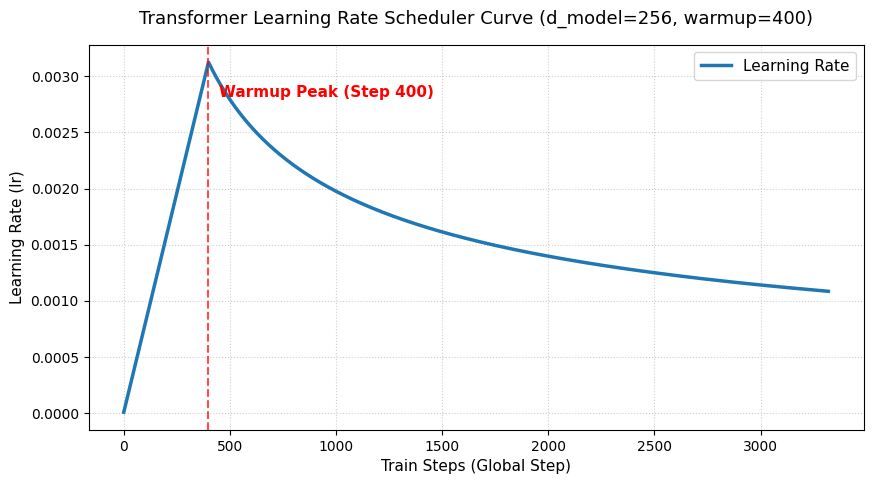

In [229]:
# 1. 앞서 선언한 스케줄러 인스턴스 준비 (테스트용)
lr_scheduler = LearningRateScheduler(d_model=D_MODEL, warmup_steps=400)

# 2. 총 10에포크 분량(약 3,320 스텝) 동안의 LR 값 시뮬레이션 추출
steps = list(range(1, 3320))
lr_values = [lr_scheduler(st) for st in steps]

# 3. 마틀랩(Matplotlib)을 이용한 시각화 디자인
plt.figure(figsize=(10, 5))
plt.plot(steps, lr_values, color='#1f77b4', linewidth=2.5, label='Learning Rate')

# 🎯 피크 지점(400스텝) 시각적 강조 표시
plt.axvline(x=400, color='red', linestyle='--', alpha=0.7)
plt.text(450, max(lr_values)*0.9, 'Warmup Peak (Step 400)', color='red', fontsize=11, fontweight='bold')

# 축 및 레이블 설정
plt.title('Transformer Learning Rate Scheduler Curve (d_model=256, warmup=400)', fontsize=13, pad=15)
plt.xlabel('Train Steps (Global Step)', fontsize=11)
plt.ylabel('Learning Rate (lr)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

- 1.2 epoch 에서 정점 찍고 내려옴.


In [230]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """
    # 💡 [보완] 전역 device 변수 대신, pred 텐서가 위치한 장치(CPU/GPU)를 자동으로 따라가게 설정
    real = real.to(pred.device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

### Dataloader

In [231]:
BATCH_SIZE = 64

In [232]:
# =====================================================================
# 📦 [그룹 1] 증강 데이터셋 (Augmented Dataset) 준비
# =====================================================================
dec_input_aug = y_train[:, :-1]   
dec_target_aug = y_train[:, 1:]   
enc_input_aug = X_train[:, :14]   

(enc_train_aug, enc_val_aug, 
 dec_train_aug, dec_val_aug, 
 tgt_train_aug, tgt_val_aug) = train_test_split(
    enc_input_aug, dec_input_aug, dec_target_aug, test_size=0.1, random_state=42
)

train_loader_aug = DataLoader(TensorDataset(
    torch.tensor(enc_train_aug, dtype=torch.long),
    torch.tensor(dec_train_aug, dtype=torch.long),
    torch.tensor(tgt_train_aug, dtype=torch.long)
), batch_size=BATCH_SIZE, shuffle=True)

In [233]:
# =====================================================================
# 📦 [그룹 2] 원본 데이터셋 (Original Dataset) 준비 
# =====================================================================
dec_input_orig = y_train_orig[:, :-1]   
dec_target_orig = y_train_orig[:, 1:]   
enc_input_orig = X_train_orig[:, :14]   

(enc_train_orig, enc_val_orig, 
 dec_train_orig, dec_val_orig, 
 tgt_train_orig, tgt_val_orig) = train_test_split(
    enc_input_orig, dec_input_orig, dec_target_orig, test_size=0.1, random_state=42
)

train_loader_orig = DataLoader(TensorDataset(
    torch.tensor(enc_train_orig, dtype=torch.long),
    torch.tensor(dec_train_orig, dtype=torch.long),
    torch.tensor(tgt_train_orig, dtype=torch.long)
), batch_size=BATCH_SIZE, shuffle=True)

In [234]:
print("✅ 두 실험군에 대한 독립적 데이터로더 구축 완료!")
print(f" 🔹 증강 모델 훈련 배치 수: {len(train_loader_aug)}개")
print(f" 🔹 원본 모델 훈련 배치 수: {len(train_loader_orig)}개")

✅ 두 실험군에 대한 독립적 데이터로더 구축 완료!
 🔹 증강 모델 훈련 배치 수: 300개
 🔹 원본 모델 훈련 배치 수: 100개


#### 📊 Ablation Study 데이터셋 및 미니배치 최종 요약

* **공통 조건:** 배치 사이즈(Batch Size) = `64` | 훈련 및 검증 분할 비율 = `9 : 1`
* **총 에포크:** `10 Epochs` 학습 기준

| 실험군 구분 | 총 데이터 개수 (Rows) | 훈련 데이터 (90%) | 검증 데이터 (10%) | **1 Epoch당 미니배치 수** | **10 Epoch 총 학습 스텝** | 최종 저장 파일명 |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **🚀 실험군 A (증강 모델)** | 21,264개 | 19,137개 | 2,127개 | **300개** | **3,000 스텝** | `transformer_augmented.pth` |
| **🌱 실험군 B (원본 모델)** | 7,088개 | 6,379개 | 709개 | **100개** | **1,000 스텝** | `transformer_original.pth` |

---

#### 📌 수치 도출 공식 및 매커니즘
1. **훈련 데이터 개수 (Training Set):** $\text{총 데이터} \times 0.9$ (소수점 버림)
2. **미니배치 개수 (Mini-batch Count):** $\text{훈련 데이터} \div 64$ (자투리 데이터 포함을 위해 PyTorch DataLoader 공식에 따라 소수점 올림 처리)
   * **증강 모델:** $19,137 \div 64 = 299.01 \rightarrow \mathbf{300 \text{ 개}}$
   * **원본 모델:** $6,379 \div 64 = 99.67 \rightarrow \mathbf{100 \text{ 개}}$
3. **Ablation Study 의의:** 데이터 증강 기법을 통해 실험군 A가 실험군 B보다 정확히 3배 많은 양(3,000 스텝)의 다양한 대화 문맥을 학습함으로써 발생하는 성능 변화를 BLEU Score로 객관적으로 추적함.

### 훈련 시작

In [235]:
def run_ablation_training_with_val(model_instance, train_loader, val_loader, optimizer, lr_scheduler, save_filename, history_filename, epochs=10, patience=3):
    """
    Train/Val 손실 기록 및 '얼리 스토핑(Early Stopping)' 기능이 내장된 마스터 훈련 함수
    """
    model_instance.to(device)
    
    # CSV 파일 초기화
    with open(history_filename, mode='w', newline='', encoding='utf-8') as f:
        csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss'])
    
    # 💡 얼리 스토핑을 위한 변수 초기화
    best_val_loss = float('inf')  # 역대 최저 검증 손실 (초기값은 무한대)
    patience_counter = 0          # 참을성 카운터
    
    global_step = 1
    print(f"\n🚀 {save_filename} 훈련 및 검증 가동 (Early Stopping patience={patience})...")
    print("=" * 60)
    
    for epoch in range(epochs):
        # --- 1. 훈련 단계 (TRAIN) ---
        model_instance.train()
        train_loss_sum = 0.0
        for src_batch, tgt_batch, target_labels in train_loader:
            src_batch, tgt_batch, target_labels = src_batch.to(device), tgt_batch.to(device), target_labels.to(device)
            
            lr = lr_scheduler(global_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
                
            optimizer.zero_grad()
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_batch, tgt_batch)
            logits, _, _, _ = model_instance(src_batch, tgt_batch, enc_mask, dec_enc_mask, dec_mask)
            
            loss = loss_function(target_labels, logits)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_instance.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss_sum += loss.item()
            global_step += 1
            
        avg_train_loss = train_loss_sum / len(train_loader)
        
        # --- 2. 검증 단계 (VALIDATION) ---
        model_instance.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for src_batch, tgt_batch, target_labels in val_loader:
                src_batch, tgt_batch, target_labels = src_batch.to(device), tgt_batch.to(device), target_labels.to(device)
                enc_mask, dec_enc_mask, dec_mask = generate_masks(src_batch, tgt_batch)
                logits, _, _, _ = model_instance(src_batch, tgt_batch, enc_mask, dec_enc_mask, dec_mask)
                val_loss_sum += loss_function(target_labels, logits).item()
                
        avg_val_loss = val_loss_sum / len(val_loader)
        print(f" 📈 Epoch [{epoch+1}/{epochs}] -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # CSV에 기록
        with open(history_filename, mode='a', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow([epoch+1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}"])
            
        # 💡 [핵심] 얼리 스토핑 로직 조건문
        if avg_val_loss < best_val_loss:
            # 역대 최고 성적이 나오면 기록을 갱신하고 카운터 리셋!
            best_val_loss = avg_val_loss
            patience_counter = 0
            # 🏆 가장 똑똑할 때의 가중치를 미리 저장 (중요)
            torch.save(model_instance.state_dict(), save_filename)
        else:
            # 성적이 나빠지거나 정체되면 참을성 카운터 증가
            patience_counter += 1
            print(f" ⚠️ 최저점 갱신 실패! (EarlyStopping Counter: {patience_counter}/{patience})")
            
            # 참을성의 한계에 도달하면 break로 for 루프 탈출
            if patience_counter >= patience:
                print(f"🛑 [Early Stopping] {epoch+1} 에포크에서 과적합 감지로 인해 학습을 조기 종료합니다.")
                print(f"🏆 최종 저장된 최적의 Val Loss: {best_val_loss:.4f}")
                break
                
    print("=" * 60)

In [236]:
# 검증 데이터셋 로더 구축
val_loader_aug = DataLoader(TensorDataset(
    torch.tensor(enc_val_aug, dtype=torch.long),
    torch.tensor(dec_val_aug, dtype=torch.long),
    torch.tensor(tgt_val_aug, dtype=torch.long)
), batch_size=BATCH_SIZE, shuffle=False)

val_loader_orig = DataLoader(TensorDataset(
    torch.tensor(enc_val_orig, dtype=torch.long),
    torch.tensor(dec_val_orig, dtype=torch.long),
    torch.tensor(tgt_val_orig, dtype=torch.long)
), batch_size=BATCH_SIZE, shuffle=False)

print("✅ 검증용 데이터로더(val_loader_aug, val_loader_orig) 준비 완료!")

✅ 검증용 데이터로더(val_loader_aug, val_loader_orig) 준비 완료!


### Augmentation 적용 Case

In [237]:
%%time

run_ablation_training_with_val(
    model_instance=model_augmented, 
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    optimizer=optimizer_aug, 
    lr_scheduler=lr_scheduler_aug,
    save_filename="transformer_augmented.pth", 
    history_filename="history_augmented.csv",
    epochs=30,
    patience=3
)


🚀 transformer_augmented.pth 훈련 및 검증 가동 (Early Stopping patience=3)...
 📈 Epoch [1/30] -> Train Loss: 1657.6233 | Val Loss: 485.0835
 📈 Epoch [2/30] -> Train Loss: 325.6967 | Val Loss: 151.0044
 📈 Epoch [3/30] -> Train Loss: 142.6562 | Val Loss: 85.0586
 📈 Epoch [4/30] -> Train Loss: 92.2533 | Val Loss: 58.0341
 📈 Epoch [5/30] -> Train Loss: 69.2783 | Val Loss: 44.6912
 📈 Epoch [6/30] -> Train Loss: 55.4803 | Val Loss: 34.9832
 📈 Epoch [7/30] -> Train Loss: 46.0479 | Val Loss: 28.2763
 📈 Epoch [8/30] -> Train Loss: 39.0391 | Val Loss: 23.6334
 📈 Epoch [9/30] -> Train Loss: 33.6308 | Val Loss: 21.1215
 📈 Epoch [10/30] -> Train Loss: 29.6159 | Val Loss: 19.2160
 📈 Epoch [11/30] -> Train Loss: 26.5116 | Val Loss: 16.0886
 📈 Epoch [12/30] -> Train Loss: 23.6870 | Val Loss: 14.1201
 📈 Epoch [13/30] -> Train Loss: 21.4641 | Val Loss: 13.3966
 📈 Epoch [14/30] -> Train Loss: 19.4293 | Val Loss: 11.7500
 📈 Epoch [15/30] -> Train Loss: 17.8877 | Val Loss: 10.9283
 📈 Epoch [16/30] -> Train Loss: 

### Augmentation 미적용 Case

In [238]:
%%time

run_ablation_training_with_val(
    model_instance=model_original, 
    train_loader=train_loader_orig,
    val_loader=val_loader_orig,
    optimizer=optimizer_orig, 
    lr_scheduler=lr_scheduler_orig,
    save_filename="transformer_original.pth", 
    history_filename="history_original.csv",
    epochs=30,
    patience=3
)


🚀 transformer_original.pth 훈련 및 검증 가동 (Early Stopping patience=3)...
 📈 Epoch [1/30] -> Train Loss: 3044.4334 | Val Loss: 1832.7825
 📈 Epoch [2/30] -> Train Loss: 1253.7449 | Val Loss: 833.6649
 📈 Epoch [3/30] -> Train Loss: 694.7833 | Val Loss: 534.9824
 📈 Epoch [4/30] -> Train Loss: 447.8977 | Val Loss: 347.5038
 📈 Epoch [5/30] -> Train Loss: 297.3989 | Val Loss: 226.0124
 📈 Epoch [6/30] -> Train Loss: 208.2252 | Val Loss: 170.5866
 📈 Epoch [7/30] -> Train Loss: 162.2398 | Val Loss: 139.4059
 📈 Epoch [8/30] -> Train Loss: 134.4537 | Val Loss: 119.1286
 📈 Epoch [9/30] -> Train Loss: 116.2588 | Val Loss: 100.8950
 📈 Epoch [10/30] -> Train Loss: 102.0326 | Val Loss: 88.4179
 📈 Epoch [11/30] -> Train Loss: 92.2646 | Val Loss: 83.7857
 📈 Epoch [12/30] -> Train Loss: 83.6325 | Val Loss: 75.0861
 📈 Epoch [13/30] -> Train Loss: 76.2087 | Val Loss: 69.0934
 📈 Epoch [14/30] -> Train Loss: 70.2670 | Val Loss: 63.9040
 📈 Epoch [15/30] -> Train Loss: 65.2911 | Val Loss: 60.1933
 📈 Epoch [16/30] 

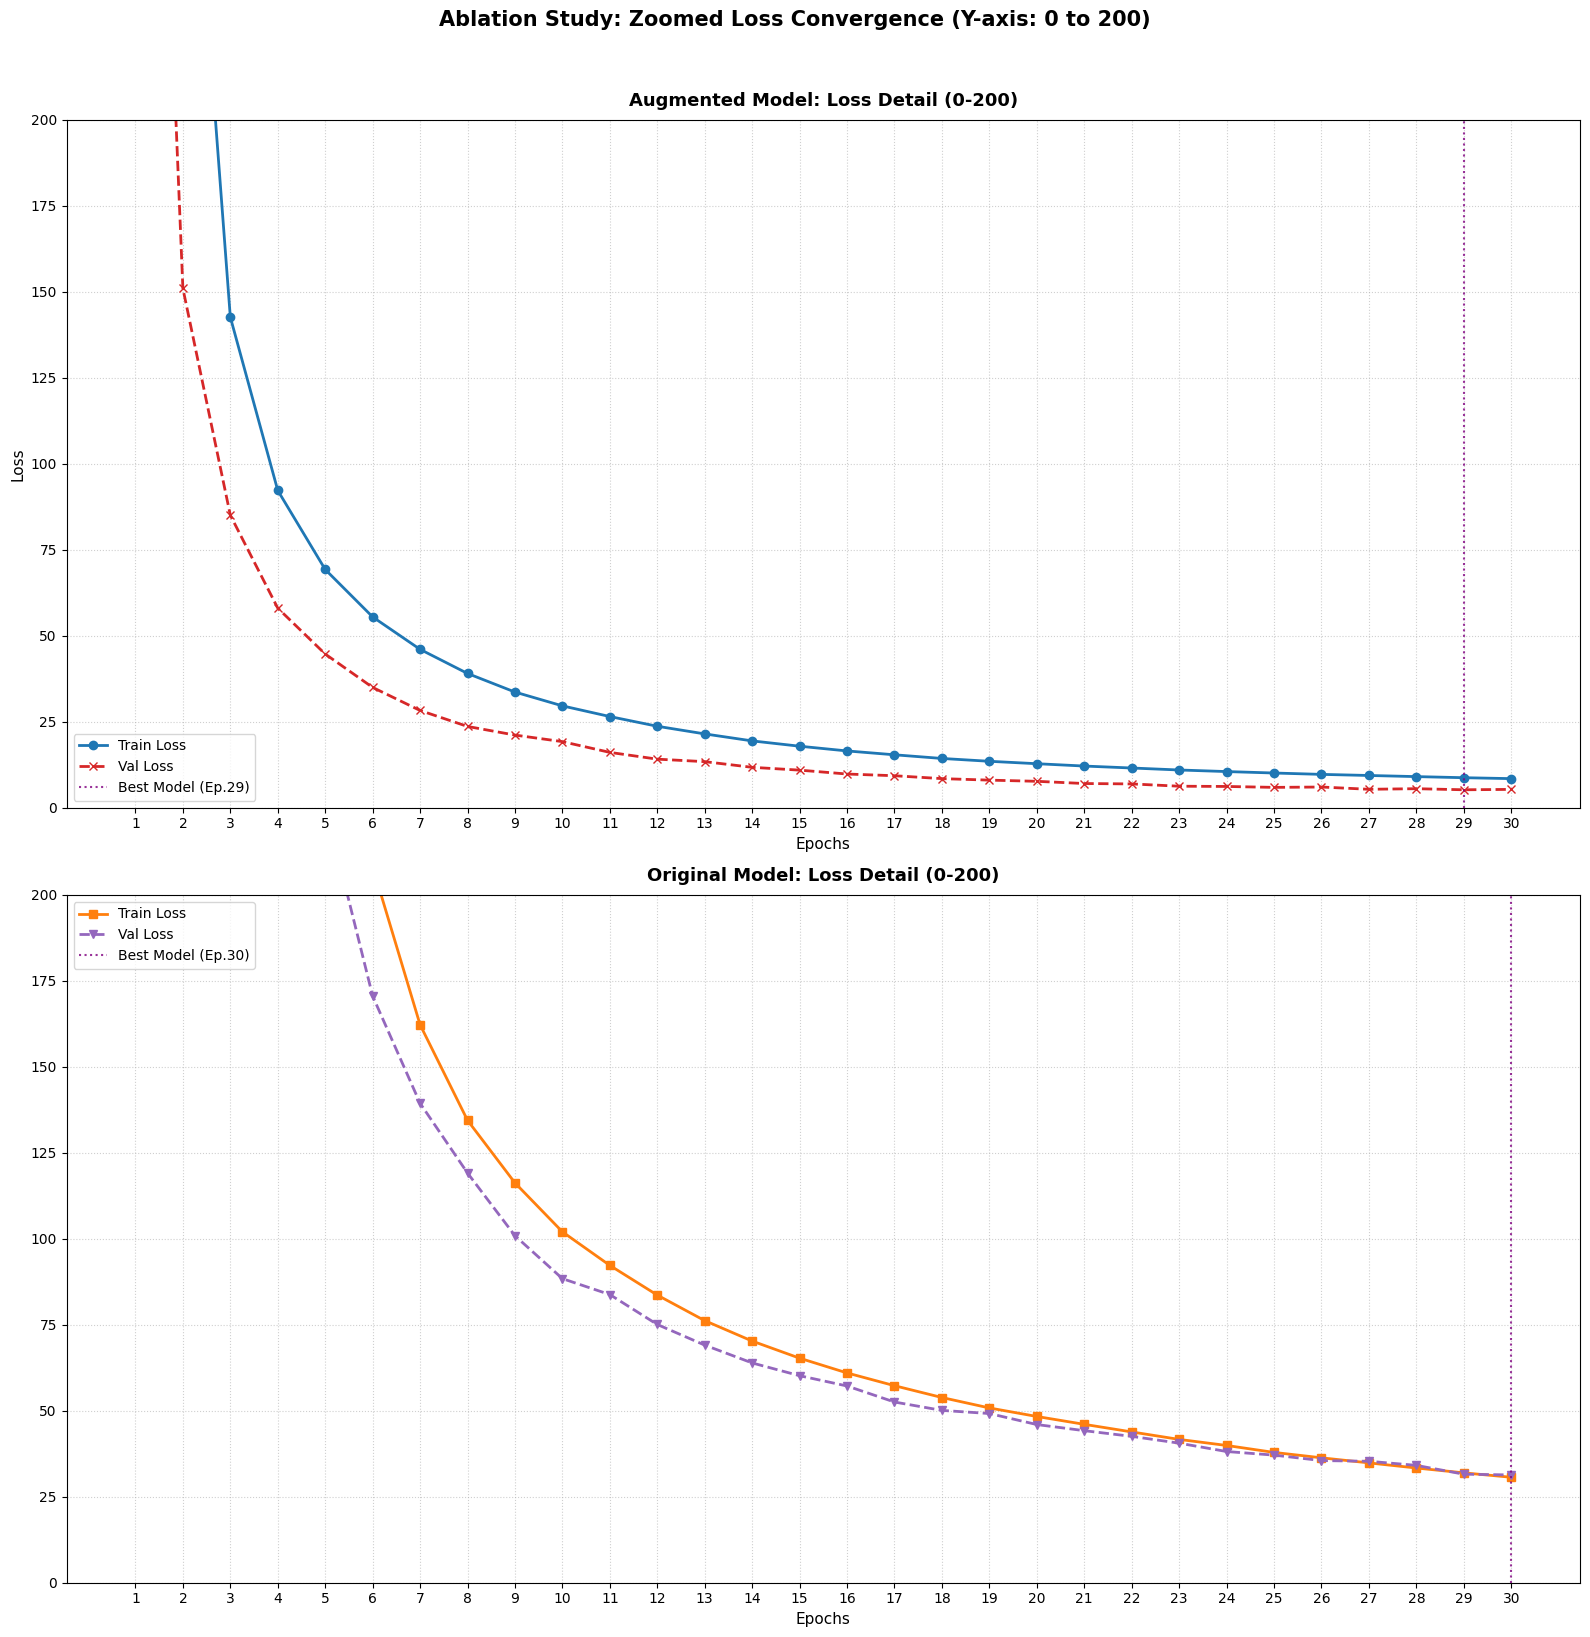

In [242]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 저장된 CSV 로그 파일 불러오기
df_aug = pd.read_csv("history_augmented.csv")
df_orig = pd.read_csv("history_original.csv")

# 2. 2행 1열 구조의 서브플롯 생성
fig, axes = plt.subplots(2, 1, figsize=(16, 16))

# 🚀 왼쪽 그래프: 실험군 A (증강 모델 - 3x 데이터셋)
axes[0].plot(df_aug['epoch'], df_aug['train_loss'], color='#1f77b4', marker='o', linewidth=2, label='Train Loss')
axes[0].plot(df_aug['epoch'], df_aug['val_loss'], color='#d62728', marker='x', linestyle='--', linewidth=2, label='Val Loss')

# 역대 최저 Val Loss 지점 찾아내기
best_epoch_aug = df_aug.loc[df_aug['val_loss'].idxmin()]['epoch']
axes[0].axvline(x=best_epoch_aug, color='purple', linestyle=':', alpha=0.8, label=f'Best Model (Ep.{int(best_epoch_aug)})')

axes[0].set_title('Augmented Model: Loss Detail (0-200)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_xticks(df_aug['epoch'])

# 💡 [핵심] Y축 범위를 0에서 200으로 강제 제한 (확대)
axes[0].set_ylim(0, 200) 
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(fontsize=10)


# 🌱 오른쪽 그래프: 실험군 B (원본 모델 - Raw 데이터셋)
axes[1].plot(df_orig['epoch'], df_orig['train_loss'], color='#ff7f0e', marker='s', linewidth=2, label='Train Loss')
axes[1].plot(df_orig['epoch'], df_orig['val_loss'], color='#9467bd', marker='v', linestyle='--', linewidth=2, label='Val Loss')

# 역대 최저 Val Loss 지점 찾아내기
best_epoch_orig = df_orig.loc[df_orig['val_loss'].idxmin()]['epoch']
axes[1].axvline(x=best_epoch_orig, color='purple', linestyle=':', alpha=0.8, label=f'Best Model (Ep.{int(best_epoch_orig)})')

axes[1].set_title('Original Model: Loss Detail (0-200)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Epochs', fontsize=11)
axes[1].set_xticks(df_orig['epoch'])

# 💡 [핵심] Y축 범위를 0에서 200으로 강제 제한 (확대)
axes[1].set_ylim(0, 200) 
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=10)

# 전체 타이틀 레이아웃 조정 및 출력
plt.suptitle('Ablation Study: Zoomed Loss Convergence (Y-axis: 0 to 200)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 학습 결과 테스트

In [248]:
PAD_ID = word_to_index.get("<PAD>", 0)
UNK_ID = word_to_index.get("<UNK>", 1)
SOS_ID = word_to_index.get("<SOS>", 2)
EOS_ID = word_to_index.get("<EOS>", 3)

test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

In [249]:
# 2. Mecab + 정확한 특수 토큰 적용 추론 함수
def generate_reply_mecab_perfect(model_instance, src_text):
    model_instance.eval()
    
    # [인코딩] 문장 -> 형태소 분할 -> word_to_index 치환
    src_tokens = [word_to_index.get(w, UNK_ID) for w in mecab.morphs(src_text)]
    
    # MAX_TOKEN_LENGTH 규격에 맞춰 패딩 처리
    if len(src_tokens) < MAX_TOKEN_LENGTH:
        src_tokens += [PAD_ID] * (MAX_TOKEN_LENGTH - len(src_tokens))
    else:
        src_tokens = src_tokens[:MAX_TOKEN_LENGTH]
        
    src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(device)
    tgt_tokens = [SOS_ID]
    
    with torch.no_grad():
        for _ in range(MAX_TOKEN_LENGTH):
            # 타겟 텐서도 MAX_TOKEN_LENGTH 고정 길이로 맞춰서 패딩 결합
            curr_tgt = tgt_tokens.copy()
            if len(curr_tgt) < MAX_TOKEN_LENGTH:
                curr_tgt += [PAD_ID] * (MAX_TOKEN_LENGTH - len(curr_tgt))
            else:
                curr_tgt = curr_tgt[:MAX_TOKEN_LENGTH]
                
            tgt_tensor = torch.tensor([curr_tgt], dtype=torch.long).to(device)
            
            # 마스크 생성 및 모델 추론
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            logits, _, _, _ = model_instance(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
            
            # 현재 생성 중인 토큰 위치의 예측값 추출
            current_idx = len(tgt_tokens) - 1
            next_token = logits[0, current_idx, :].argmax().item()
            
            tgt_tokens.append(next_token)
            if next_token == EOS_ID or len(tgt_tokens) >= MAX_TOKEN_LENGTH:
                break
                
    # [디코딩] 정의해주신 4가지 특수 토큰 문자열들을 제외하고 한글만 필터링
    special_tokens = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
    decoded_words = [index_to_word.get(t, "") for t in tgt_tokens]
    filtered_words = [w for w in decoded_words if w not in special_tokens and w != ""]
    
    return " ".join(filtered_words).strip()

In [250]:
# 3. 🚀 [실험군 A] 증강 모델 결과 출력
print("=============================================================")
print("🚀 [실험군 A] 증강 모델 (transformer_augmented.pth) 추론 결과")
print("=============================================================")
model_augmented.load_state_dict(torch.load("transformer_augmented.pth", map_location=device))

for i, src in enumerate(test_sentences, 1):
    reply = generate_reply_mecab_perfect(model_augmented, src)
    print(f"질문 {i}: {src}")
    print(f"답변  : {reply}")
    print("-" * 50)

print("\n")

# 4. 🌱 [실험군 B] 원본 모델 결과 출력
print("=============================================================")
print("🌱 [실험군 B] 원본 모델 (transformer_original.pth) 추론 결과")
print("=============================================================")
model_original.load_state_dict(torch.load("transformer_original.pth", map_location=device))

for i, src in enumerate(test_sentences, 1):
    reply = generate_reply_mecab_perfect(model_original, src)
    print(f"질문 {i}: {src}")
    print(f"답변  : {reply}")
    print("-" * 50)

🚀 [실험군 A] 증강 모델 (transformer_augmented.pth) 추론 결과
질문 1: 지루하다, 놀러가고 싶어.
답변  : 월급 이 라면 정리 하 세요 .
--------------------------------------------------
질문 2: 오늘 일찍 일어났더니 피곤하다.
답변  : 월급 이 네요 .
--------------------------------------------------
질문 3: 간만에 여자친구랑 데이트 하기로 했어.
답변  : 소중 한 만큼 말 해 보 세요 .
--------------------------------------------------
질문 4: 집에 있는다는 소리야.
답변  : 다시 시작 을 하 지 마세요 .
--------------------------------------------------


🌱 [실험군 B] 원본 모델 (transformer_original.pth) 추론 결과
질문 1: 지루하다, 놀러가고 싶어.
답변  : 자신 이 됩니다 .
--------------------------------------------------
질문 2: 오늘 일찍 일어났더니 피곤하다.
답변  : 우리 는 건 생각 이 연락 이 연락 이 연락 이 연락 이 연락
--------------------------------------------------
질문 3: 간만에 여자친구랑 데이트 하기로 했어.
답변  : 좋 은 귀 기울여 보 세요 .
--------------------------------------------------
질문 4: 집에 있는다는 소리야.
답변  : 사랑 은 알 는 존재 자체 가 도움 이 힘 이 는 존재 자체
--------------------------------------------------


### 폰트설정

현재 설정된 폰트: ['NanumBarunGothic']


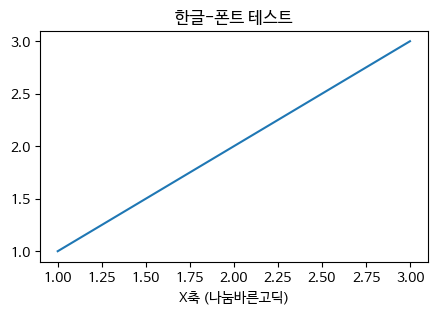

In [255]:
import logging
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker


# 폰트 매니저 관련 불필요한 로그 끄기
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 윈도우에 설치된 나눔바른고딕 경로 설정
fontpath = "C:/Users/sr/AppData/Local/Microsoft/Windows/Fonts/NanumBarunGothic.ttf"

# 폰트 속성 적용
font_name = fm.FontProperties(fname=fontpath).get_name()

# 폰트 매니저에 폰트 추가 (윈도우 환경에서 안정성 확보)
fm.fontManager.addfont(fontpath)

# 전역 설정 업데이트
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

plt.figure(figsize=(5, 3))
plt.title("한글-폰트 테스트")
plt.plot([1, 2, 3], [1, 2, 3])
plt.xlabel("X축 (나눔바른고딕)")
plt.show()

C:\Users\sr\AppData\Local\Temp\ipykernel_18532\288357759.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_aug.set_xticklabels([''] + words_aug, rotation=90, fontsize=10)
C:\Users\sr\AppData\Local\Temp\ipykernel_18532\288357759.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_aug.set_yticklabels([''] + words_aug, fontsize=10)
C:\Users\sr\AppData\Local\Temp\ipykernel_18532\288357759.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_orig.set_xticklabels([''] + words_orig, rotation=90, fontsize=10)
C:\Users\sr\AppData\Local\Temp\ipykernel_18532\288357759.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_orig.set_yticklabels([''] + wor

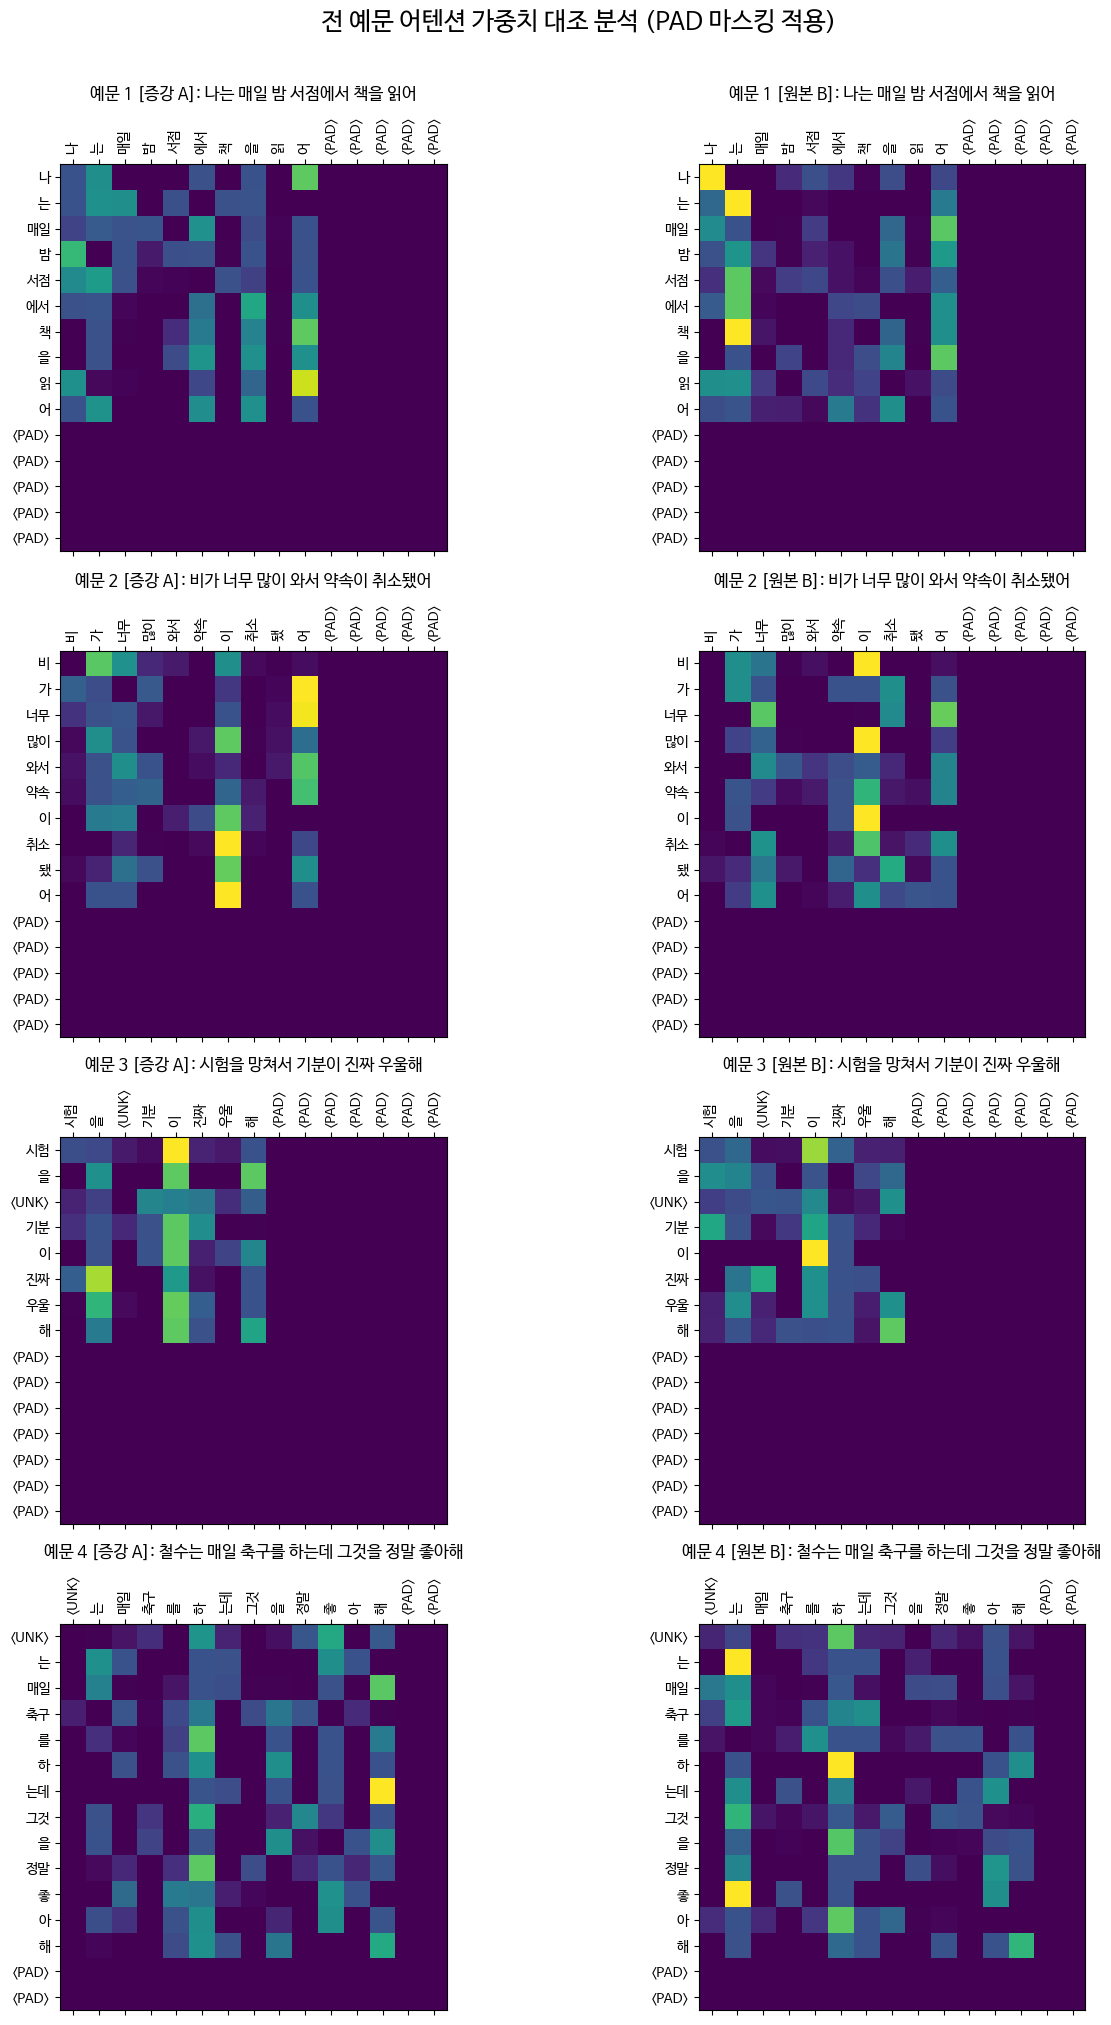

In [260]:


# 1. 특화 예문 세트
test_sentences2 = [
    "나는 매일 밤 서점에서 책을 읽어",          # 1. 주어-목적어-동사 관계 (행동 매칭)
    "비가 너무 많이 와서 약속이 취소됐어",      # 2. 인과 관계 (장기 의존성 검증)
    "시험을 망쳐서 기분이 진짜 우울해",          # 3. 감정-원인 관계 (챗봇 문맥 파악)
    "철수는 매일 축구를 하는데 그것을 정말 좋아해" # 4. 대명사 지칭 관계 (Context 해결)
]

# 2. 4행 2열 구조의 도화지 생성
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

def get_clean_attention_matrix(model_instance, src_text):
    """PAD 영역을 강제로 0 처리하고 2차원 평균 어텐션 행렬을 반환하는 함수"""
    model_instance.eval()
    
    # 형태소 분할 및 실제 단어 길이 측정
    raw_morphs = mecab.morphs(src_text)
    actual_len = len(raw_morphs)
    
    src_tokens = [word_to_index.get(w, UNK_ID) for w in raw_morphs]
    src_words = [index_to_word.get(t, "<UNK>") for t in src_tokens]
    
    # MAX_TOKEN_LENGTH 고정 패딩 (15)
    if len(src_tokens) < MAX_TOKEN_LENGTH:
        diff = MAX_TOKEN_LENGTH - len(src_tokens)
        src_tokens += [PAD_ID] * diff
        src_words += ["<PAD>"] * diff
    else:
        src_tokens = src_tokens[:MAX_TOKEN_LENGTH]
        src_words = src_words[:MAX_TOKEN_LENGTH]
        
    src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(device)
    dummy_tgt = [SOS_ID] + [PAD_ID] * (MAX_TOKEN_LENGTH - 1)
    tgt_tensor = torch.tensor([dummy_tgt], dtype=torch.long).to(device)
    
    with torch.no_grad():
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
        _, enc_attns, _, _ = model_instance(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
        
    if isinstance(enc_attns, list) or isinstance(enc_attns, tuple):
        raw_matrix = enc_attns[0]
    else:
        raw_matrix = enc_attns
        
    # 8개 헤드 평균 내기
    if raw_matrix.ndim == 4:
        matrix = raw_matrix[0].mean(axis=0).cpu().numpy()
    elif raw_matrix.ndim == 3:
        matrix = raw_matrix.mean(axis=0).cpu().numpy()
    else:
        matrix = raw_matrix.cpu().numpy()
        
    # 💡 [핵심 방어 코드] <PAD> 토큰이 들어오는 행과 열을 강제로 0(최저값) 처리
    # 실제 문장 길이(actual_len) 이후의 인덱스는 전부 불을 끕니다.
    matrix[actual_len:, :] = 0.0
    matrix[:, actual_len:] = 0.0
        
    return matrix, src_words

# 3. 모델 가중치 로드
model_augmented.load_state_dict(torch.load("transformer_augmented.pth", map_location=device))
model_original.load_state_dict(torch.load("transformer_original.pth", map_location=device))

# 4. 루프를 돌며 시각화 채우기
for idx, src in enumerate(test_sentences2):
    # --- 왼쪽: 데이터 증강 모델 (A) ---
    mat_aug, words_aug = get_clean_attention_matrix(model_augmented, src)
    ax_aug = axes[idx, 0]
    # vmin, vmax 설정을 통해 패딩의 0값과 실제 단어의 대비를 극대화
    ax_aug.matshow(mat_aug, cmap='viridis', vmin=0.0, vmax=matrix_max if 'matrix_max' in locals() else 0.5)
    
    ax_aug.set_title(f"예문 {idx+1} [증강 A]: {src}", fontsize=12, fontweight='bold', pad=12)
    ax_aug.set_xticklabels([''] + words_aug, rotation=90, fontsize=10)
    ax_aug.set_yticklabels([''] + words_aug, fontsize=10)
    ax_aug.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax_aug.yaxis.set_major_locator(ticker.MultipleLocator(1))
    
    # --- 오른쪽: 원본 모델 (B) ---
    mat_orig, words_orig = get_clean_attention_matrix(model_original, src)
    ax_orig = axes[idx, 1]
    ax_orig.matshow(mat_orig, cmap='viridis', vmin=0.0, vmax=0.5)
    
    ax_orig.set_title(f"예문 {idx+1} [원본 B]: {src}", fontsize=12, fontweight='bold', pad=12)
    ax_orig.set_xticklabels([''] + words_orig, rotation=90, fontsize=10)
    ax_orig.set_yticklabels([''] + words_orig, fontsize=10)
    ax_orig.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax_orig.yaxis.set_major_locator(ticker.MultipleLocator(1))

# 💡 우측 세로 막대바(colorbar) 관련 코드 완전 제거
plt.suptitle("🏆 전 예문 어텐션 가중치 대조 분석 (PAD 마스킹 적용)", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 7. BLEU

In [261]:
# =====================================================================
# [상수 세팅] 이전 단계에서 확인한 특수 토큰 및 규격 연동
# =====================================================================
PAD_ID = word_to_index.get("<PAD>", 0)
UNK_ID = word_to_index.get("<UNK>", 1)
SOS_ID = word_to_index.get("<SOS>", 2)
EOS_ID = word_to_index.get("<EOS>", 3)

# 1. Mecab 환경에 최적화된 텍스트 생성(디코딩) 함수
def translate_mecab(tokens_list, model):
    model.eval()
    
    # MAX_TOKEN_LENGTH 길이에 맞춰 입력 토큰 패딩 처리
    if len(tokens_list) > MAX_TOKEN_LENGTH:
        tokens_list = tokens_list[:MAX_TOKEN_LENGTH]
    else:
        tokens_list = tokens_list + [PAD_ID] * (MAX_TOKEN_LENGTH - len(tokens_list))
        
    padded_tokens = torch.tensor([tokens_list], dtype=torch.long, device=device)
    
    generated_ids = []
    # 디코더의 첫 시작은 SOS_ID로 시작
    output = torch.tensor([[SOS_ID]], dtype=torch.long, device=device)
    
    with torch.no_grad():
        for i in range(MAX_TOKEN_LENGTH):
            enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)
            
            # 현재까지의 입력 기반 예측
            predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)
            
            # 마지막 타임스텝의 예측 토큰 추출
            predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()
            
            # EOS 토큰에 도달하면 즉시 중단하고 반환
            if predicted_id == EOS_ID:
                break
                
            generated_ids.append(predicted_id)
            
            # 다음 턴 입력을 위해 output 뒤에 새로운 토큰 이어 붙이기
            new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
            output = torch.cat([output, new_token], dim=1)
            
            if output.size(1) >= MAX_TOKEN_LENGTH:
                break
                
    # 토큰 ID 배열을 한국어 단어 형태로 디코딩
    decoded_words = [index_to_word.get(tid, "") for tid in generated_ids if tid not in [PAD_ID, SOS_ID, EOS_ID]]
    return " ".join(decoded_words).strip()




In [262]:
# 2. 예문 1개에 대해 정밀하게 BLEU 점수를 산출하는 함수
def eval_bleu_single_mecab(model, src_sentence, tgt_sentence, verbose=True):
    # Mecab 형태소 분할 후 인덱스 시퀀스로 인코딩
    src_tokens = [word_to_index.get(w, UNK_ID) for w in mecab.morphs(src_sentence)]
    tgt_tokens = [word_to_index.get(w, UNK_ID) for w in mecab.morphs(tgt_sentence)]
    
    # 최대 길이를 초과하는 에러 데이터 처리 거르기
    if len(src_tokens) > MAX_TOKEN_LENGTH or len(tgt_tokens) > MAX_TOKEN_LENGTH:
        return None
        
    # BLEU 측정을 위해 형태소 단위로 쪼갠 리스트 생성
    reference = mecab.morphs(tgt_sentence)
    
    # 모델의 추론 결과 도출 및 형태소 분할
    pred_string = translate_mecab(src_tokens, model)
    candidate = mecab.morphs(pred_string)
    
    # SmoothingFunction을 적용하여 단어 매칭이 적더라도 스코어가 0이 되지 않도록 방어
    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1)
    
    if verbose:
        print(f"입력 문장(Source) : {src_sentence}")
        print(f"모델 답변(Predict) : {' '.join(candidate)}")
        print(f"실제 정답(Target)  : {' '.join(reference)}")
        print(f"BLEU Score         : {score:.4f}")
        print("-" * 60)
        
    return score




In [263]:
# 3. 데이터셋 전체 리스트를 돌며 평균 BLEU 점수를 산출하는 함수
def eval_bleu_mecab(model, src_sentences, tgt_sentences, verbose=False):
    total_score = 0.0
    valid_sample_count = 0
    
    # tqdm을 사용해 진행률 표시
    for idx in tqdm(range(len(src_sentences))):
        score = eval_bleu_single_mecab(model, src_sentences[idx], tgt_sentences[idx], verbose=verbose)
        if score is None: 
            continue
            
        total_score += score
        valid_sample_count += 1
        
    avg_score = total_score / valid_sample_count if valid_sample_count > 0 else 0.0
    print(f"\n[평가 완료] 최종 검증 샘플 수: {valid_sample_count}")
    print(f"🏆 전체 평균 BLEU Score: {avg_score:.4f}")
    return avg_score

In [264]:
# 1. 예문에 매칭되는 가상의 실제 정답(Target) 답변 정의
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
] 

test_targets = [
    "맛있는 거 드시고 오세요 .",           # 질문 1에 대한 정답
    "푹 쉬 시 는 게 좋 겠 어요 .",         # 질문 2에 대한 정답
    "좋 은 시간 보내 고 오 세요 .",         # 질문 3에 대한 정답
    "집 에서 쉬 는 것도 좋 지요 ."          # 질문 4에 대한 정답
]

print("=" * 65)
print("🚀 [실험군 A] 데이터 증강 모델 (transformer_augmented.pth) BLEU 평가")
print("=" * 65)
# 가중치 파일 로드 확인
model_augmented.load_state_dict(torch.load("transformer_augmented.pth", map_location=device))

total_score_a = 0.0
for idx in range(len(test_sentences)):
    print(f"[예제 {idx+1}]")
    score = eval_bleu_single_mecab(model_augmented, test_sentences[idx], test_targets[idx], verbose=True)
    if score:
        total_score_a += score

print(f"📊 [실험군 A] 4개 예문 평균 BLEU 스코어: {total_score_a / len(test_sentences):.4f}\n\n")


print("=" * 65)
print("🌱 [실험군 B] 원본 모델 (transformer_original.pth) BLEU 평가")
print("=" * 65)
# 가중치 파일 로드 확인
model_original.load_state_dict(torch.load("transformer_original.pth", map_location=device))

total_score_b = 0.0
for idx in range(len(test_sentences)):
    print(f"[예제 {idx+1}]")
    score = eval_bleu_single_mecab(model_original, test_sentences[idx], test_targets[idx], verbose=True)
    if score:
        total_score_b += score

print(f"📊 [실험군 B] 4개 예문 평균 BLEU 스코어: {total_score_b / len(test_sentences):.4f}")

🚀 [실험군 A] 데이터 증강 모델 (transformer_augmented.pth) BLEU 평가
[예제 1]
입력 문장(Source) : 지루하다, 놀러가고 싶어.
모델 답변(Predict) : 월급 이 라면 정리 하 세요 .
실제 정답(Target)  : 맛있 는 거 드 시 고 오 세요 .
BLEU Score         : 0.0525
------------------------------------------------------------
[예제 2]
입력 문장(Source) : 오늘 일찍 일어났더니 피곤하다.
모델 답변(Predict) : 월급 이 네요 .
실제 정답(Target)  : 푹 쉬 시 는 게 좋 겠 어요 .
BLEU Score         : 0.0230
------------------------------------------------------------
[예제 3]
입력 문장(Source) : 간만에 여자친구랑 데이트 하기로 했어.
모델 답변(Predict) : 소중 한 만큼 말 해 보 세요 .
실제 정답(Target)  : 좋 은 시간 보내 고 오 세요 .
BLEU Score         : 0.0587
------------------------------------------------------------
[예제 4]
입력 문장(Source) : 집에 있는다는 소리야.
모델 답변(Predict) : 다시 시작 을 하 지 마세요 .
실제 정답(Target)  : 집 에서 쉬 는 것 도 좋 지요 .
BLEU Score         : 0.0248
------------------------------------------------------------
📊 [실험군 A] 4개 예문 평균 BLEU 스코어: 0.0398


🌱 [실험군 B] 원본 모델 (transformer_original.pth) BLEU 평가
[예제 1]
입력 문장(Source) : 지루하다, 놀러가고 싶어.
모델 답변(Predict) : 자신 이 

## 회고

- Keep
    - 데이터 증강을 통한 모델 수렴도 개선
    - 어텐션 맵 평균화를 통한 시각화 고도화

- Problem
    - 학습과 추론 간의 파라미터 불일치 에러
    - 챗봇 답변의 단어 편향(Bias) 발생
    - BLEU 스코어의 근본적 한계

- Try
    - 데이터 증강 밸런싱 및 다양화
    - 챗봇 전용 평가 지표 도입 (BERTScore, Perplexity)
